In [ ]:
import pandas as pd

PATH = "/content/tweeteval/datasets/sentiment"

label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

def load_split(split):

    with open(
        f"{PATH}/{split}_text.txt",
        "r",
        encoding="utf-8"
    ) as f:
        texts = [line.rstrip("\n") for line in f]

    with open(
        f"{PATH}/{split}_labels.txt",
        "r",
        encoding="utf-8"
    ) as f:
        labels = [int(line.strip()) for line in f]

    df = pd.DataFrame({
        "text": texts,
        "label": labels
    })

    df["sentiment"] = df["label"].map(label_map)

    return df

In [ ]:
!git clone https://github.com/cardiffnlp/tweeteval.git

Cloning into 'tweeteval'...
remote: Enumerating objects: 370, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 370 (delta 13), reused 3 (delta 1), pack-reused 354 (from 1)
Receiving objects: 100% (370/370), 8.49 MiB | 11.99 MiB/s, done.
Resolving deltas: 100% (122/122), done.


In [ ]:
!ls /content/tweeteval/datasets/sentiment

mapping.txt	 test_text.txt	   train_text.txt  val_text.txt
test_labels.txt  train_labels.txt  val_labels.txt


In [ ]:
train_df = load_split("train")
val_df = load_split("val")
test_df = load_split("test")

In [ ]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (45615, 3)
Validation: (2000, 3)
Test: (12284, 3)


In [ ]:
train_df.head()

,text,label,sentiment
0,"""QT @user In the original draft of the 7th boo...",2,positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,neutral
2,Sorry bout the stream last night I crashed out...,1,neutral
3,Chase Headley's RBI double in the 8th inning o...,1,neutral
4,@user Alciato: Bee will invest 150 million in ...,2,positive


In [ ]:
print(train_df["sentiment"].value_counts())

print(
    train_df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
)

sentiment
neutral     20673
positive    17849
negative     7093
Name: count, dtype: int64
sentiment
neutral     45.320618
positive    39.129672
negative    15.549710
Name: proportion, dtype: float64


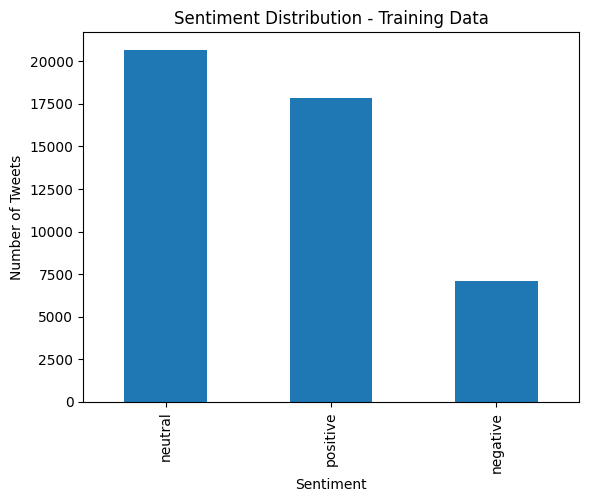

In [ ]:
import matplotlib.pyplot as plt

train_df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution - Training Data")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()
#The dataset is imbalanced, evaluation should not rely only on accuracy, but also on macro F1-score, precision, and recall.

In [ ]:
# Check missing and duplicate value
print(train_df.isnull().sum())

print("Duplicate tweets:",
      train_df["text"].duplicated().sum())

text         0
label        0
sentiment    0
dtype: int64
Duplicate tweets: 28


In [ ]:
# Check for empty tweets
print(
    (train_df["text"].str.strip() == "").sum()
)

0


In [ ]:
# Tweet length analysis
# Character count and word count
train_df["char_length"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

train_df[["char_length", "word_count"]].describe()


,char_length,word_count
count,45615.000000,45615.000000
mean,107.956023,19.237444
std,26.236406,4.935990
min,11.000000,1.000000
25%,90.000000,16.000000
50%,114.000000,20.000000
75%,129.000000,23.000000
max,201.000000,35.000000


In [ ]:
# Based on sentiment
train_df.groupby("sentiment")[
    ["char_length", "word_count"]
].mean()

,char_length,word_count
sentiment,,
negative,113.154519,20.218525
neutral,107.015286,18.979732
positive,106.979775,19.146059


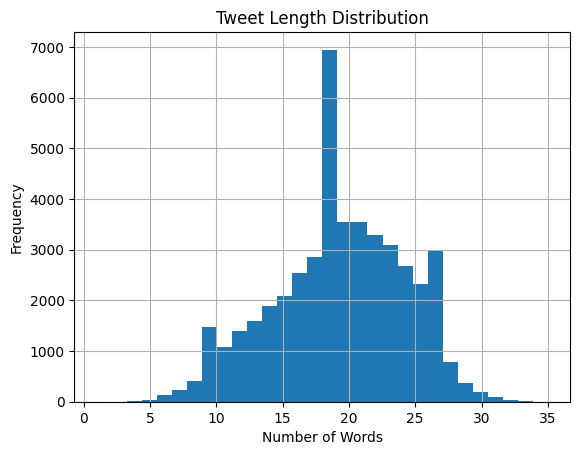

In [ ]:
# Visualize
train_df["word_count"].hist(bins=30)

plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Tweet Length Distribution")
plt.show()
# Most tweets contain around 15–27 words, with the highest frequency around 18–20 words. Very short and very long tweets are less common.

In [ ]:
# EDA of Twitter's distinctive features
train_df["has_url"] = train_df["text"].str.contains(
    r"http\S+|www\S+",
    regex=True
)

train_df["has_mention"] = train_df["text"].str.contains(
    r"@\w+",
    regex=True
)

train_df["has_hashtag"] = train_df["text"].str.contains(
    r"#\w+",
    regex=True
)

print("URL:", train_df["has_url"].mean())
print("Mention:", train_df["has_mention"].mean())
print("Hashtag:", train_df["has_hashtag"].mean())
# Mentions are the most common Twitter-specific feature (29.44%), followed by hashtags (18.69%), while URLs are rarely found (0.22%)

URL: 0.0021922613175490518
Mention: 0.2943987723336622
Hashtag: 0.18691219993423216


In [ ]:
train_text = set(train_df["text"])
test_text = set(test_df["text"])

overlap = train_text.intersection(test_text)

print("Train-test overlap:", len(overlap))
# No obvious data leakage across the splits.

Train-test overlap: 0


In [ ]:
train_val_overlap = set(train_df["text"]) & set(val_df["text"])
val_test_overlap = set(val_df["text"]) & set(test_df["text"])

print(len(train_val_overlap))
print(len(val_test_overlap))

0
0


In [ ]:
train_df["has_mention"]
train_df["has_hashtag"]
train_df["sentiment"]

,sentiment
0,positive
1,neutral
2,neutral
3,neutral
4,positive
...,...
45610,positive
45611,positive
45612,positive
45613,neutral


In [ ]:
# Count
count_table = train_df.groupby("sentiment")[
    ["has_mention", "has_hashtag", "has_url"]
].sum()

# Percentage
percentage_table = train_df.groupby("sentiment")[
    ["has_mention", "has_hashtag", "has_url"]
].mean() * 100

# Gabungkan count dan percentage
result = count_table.astype(str) + " (" + percentage_table.round(2).astype(str) + "%)"

result

,has_mention,has_hashtag,has_url
sentiment,,,
negative,2032 (28.65%),1064 (15.0%),22 (0.31%)
neutral,5897 (28.53%),3859 (18.67%),52 (0.25%)
positive,5500 (30.81%),3603 (20.19%),26 (0.15%)


In [ ]:
result.columns = ["Mention", "Hashtag", "URL"]

result

,Mention,Hashtag,URL
sentiment,,,
negative,2032 (28.65%),1064 (15.0%),22 (0.31%)
neutral,5897 (28.53%),3859 (18.67%),52 (0.25%)
positive,5500 (30.81%),3603 (20.19%),26 (0.15%)


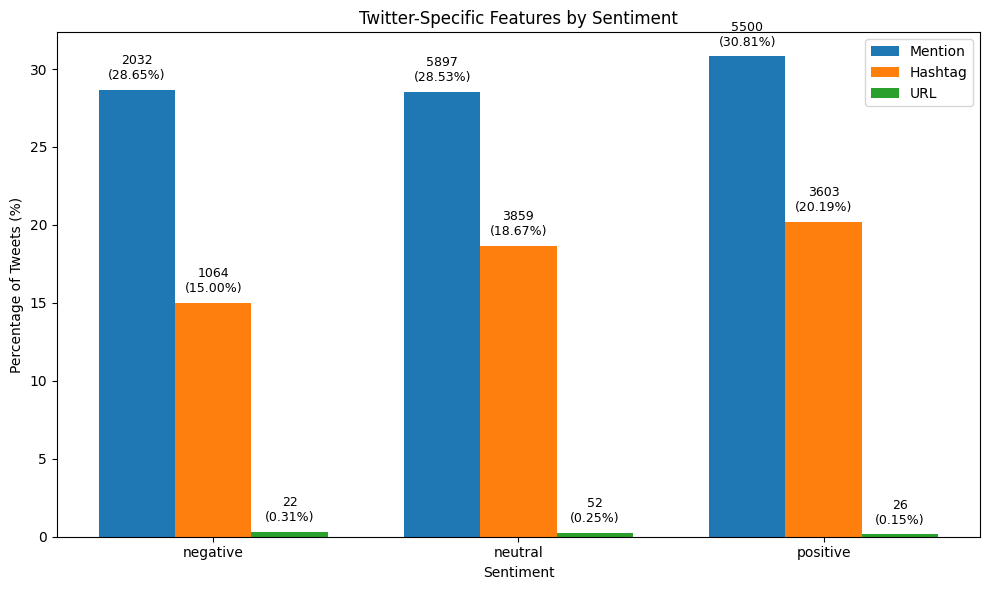

In [ ]:
import numpy as np
features = ["has_mention", "has_hashtag", "has_url"]

# Count
count_table = train_df.groupby("sentiment")[features].sum()

# Percentage
percentage_table = (
    train_df.groupby("sentiment")[features].mean() * 100
)

# Urutan sentiment
order = ["negative", "neutral", "positive"]

count_table = count_table.loc[order]
percentage_table = percentage_table.loc[order]

# Rename
labels = ["Mention", "Hashtag", "URL"]

x = np.arange(len(order))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, feature in enumerate(features):

    bars = ax.bar(
        x + (i - 1) * width,
        percentage_table[feature],
        width,
        label=labels[i]
    )

    # Tambahkan Count + Percentage
    for j, bar in enumerate(bars):

        count = int(count_table.iloc[j][feature])
        percentage = percentage_table.iloc[j][feature]

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{count}\n({percentage:.2f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title("Twitter-Specific Features by Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Percentage of Tweets (%)")

ax.set_xticks(x)
ax.set_xticklabels(order)

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
!pip install -q transformers torch scikit-learn

In [ ]:
def preprocess_tweet(text):
    new_text = []

    for token in text.split():
        if token.startswith("@") and len(token) > 1:
            token = "@user"
        elif token.startswith("http"):
            token = "http"

        new_text.append(token)

    return " ".join(new_text)

In [ ]:
test_df["clean_text"] = test_df["text"].apply(preprocess_tweet)

In [ ]:
test_df[["text", "clean_text"]].head()

,text,clean_text
0,@user @user what do these '1/2 naked pics' hav...,@user @user what do these '1/2 naked pics' hav...
1,OH: “I had a blue penis while I was this” [pla...,OH: “I had a blue penis while I was this” [pla...
2,"@user @user That's coming, but I think the vic...","@user @user That's coming, but I think the vic..."
3,I think I may be finally in with the in crowd ...,I think I may be finally in with the in crowd ...
4,"@user Wow,first Hugo Chavez and now Fidel Cast...","@user Wow,first Hugo Chavez and now Fidel Cast..."


In [ ]:
(test_df["text"] != test_df["clean_text"]).sum()

np.int64(12284)

In [ ]:
changed = test_df[
    test_df["text"] != test_df["clean_text"]
][["text", "clean_text"]]

changed.head(20)

,text,clean_text
0,@user @user what do these '1/2 naked pics' hav...,@user @user what do these '1/2 naked pics' hav...
1,OH: “I had a blue penis while I was this” [pla...,OH: “I had a blue penis while I was this” [pla...
2,"@user @user That's coming, but I think the vic...","@user @user That's coming, but I think the vic..."
3,I think I may be finally in with the in crowd ...,I think I may be finally in with the in crowd ...
4,"@user Wow,first Hugo Chavez and now Fidel Cast...","@user Wow,first Hugo Chavez and now Fidel Cast..."
5,Savchenko now Saakashvili took drug test live ...,Savchenko now Saakashvili took drug test live ...
6,How many more days until opening day? 😩,How many more days until opening day? 😩
7,Twitter's #ThankYouObama Shows Heartfelt Grati...,Twitter's #ThankYouObama Shows Heartfelt Grati...
8,All CSG and Fracking all around Australia is t...,All CSG and Fracking all around Australia is t...
9,@user @user @user @user @user @user take away ...,@user @user @user @user @user @user take away ...


In [ ]:
for i in changed.index[:10]:
    print("ORIGINAL :", repr(test_df.loc[i, "text"]))
    print("CLEAN    :", repr(test_df.loc[i, "clean_text"]))
    print("-" * 100)

ORIGINAL : "@user @user what do these '1/2 naked pics' have to do with anything? They're not even like that. "
CLEAN    : "@user @user what do these '1/2 naked pics' have to do with anything? They're not even like that."
----------------------------------------------------------------------------------------------------
ORIGINAL : 'OH: “I had a blue penis while I was this” [playing with Google Earth VR] '
CLEAN    : 'OH: “I had a blue penis while I was this” [playing with Google Earth VR]'
----------------------------------------------------------------------------------------------------
ORIGINAL : "@user @user That's coming, but I think the victims are going to be Medicaid recipients. "
CLEAN    : "@user @user That's coming, but I think the victims are going to be Medicaid recipients."
----------------------------------------------------------------------------------------------------
ORIGINAL : 'I think I may be finally in with the in crowd #mannequinchallenge  #grads2014 @user '
CL

In [ ]:
url_count = test_df["text"].str.contains(
    r"http\S+",
    regex=True
).sum()

print("Tweets containing URL:", url_count)

Tweets containing URL: 377


In [ ]:
import re

other_mentions = test_df["text"].apply(
    lambda x: bool(
        re.search(r"@(?!user\b)\w+", x)
    )
).sum()

print("Tweets with non-@user mentions:", other_mentions)

Tweets with non-@user mentions: 272


In [ ]:
normalized_original = test_df["text"].apply(
    lambda x: " ".join(x.split())
)

whitespace_changes = (
    test_df["text"] != normalized_original
).sum()

print("Changes caused by whitespace:", whitespace_changes)

Changes caused by whitespace: 12284


In [ ]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

roberta = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
texts = test_df["clean_text"].tolist()

predictions = roberta(
    texts,
    batch_size=64,
    truncation=True,
    max_length=128
)

In [ ]:
print("Amount test data:", len(test_df))
print("Amount prediction:", len(predictions))

print(predictions[:5])

Amount test data: 12284
Amount prediction: 12284
[{'label': 'negative', 'score': 0.8047259449958801}, {'label': 'neutral', 'score': 0.8669488430023193}, {'label': 'neutral', 'score': 0.7637244462966919}, {'label': 'positive', 'score': 0.7859702110290527}, {'label': 'neutral', 'score': 0.4163972735404968}]


In [ ]:
test_df["roberta_pred"] = [
    pred["label"].lower()
    for pred in predictions
]

In [ ]:
test_df[
    ["text", "sentiment", "roberta_pred"]
].head(10)

,text,sentiment,roberta_pred
0,@user @user what do these '1/2 naked pics' hav...,neutral,negative
1,OH: “I had a blue penis while I was this” [pla...,neutral,neutral
2,"@user @user That's coming, but I think the vic...",neutral,neutral
3,I think I may be finally in with the in crowd ...,positive,positive
4,"@user Wow,first Hugo Chavez and now Fidel Cast...",negative,neutral
5,Savchenko now Saakashvili took drug test live ...,neutral,neutral
6,How many more days until opening day? 😩,neutral,neutral
7,Twitter's #ThankYouObama Shows Heartfelt Grati...,positive,positive
8,All CSG and Fracking all around Australia is t...,neutral,negative
9,@user @user @user @user @user @user take away ...,negative,neutral


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score
)

# Actual label
y_true = test_df["sentiment"]

# Predicted label
y_pred = test_df["roberta_pred"]

# Accuracy
print("Accuracy:",
      accuracy_score(y_true, y_pred))

# Macro F1
print("Macro F1:",
      f1_score(
          y_true,
          y_pred,
          average="macro"
      ))

# Macro Recall
print("Macro Recall:",
      recall_score(
          y_true,
          y_pred,
          average="macro"
      ))

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred
    )
)
# Twitter-RoBERTa achieved 72.22% accuracy, 72.44% Macro F1, and 73.54% Macro Recall. Negative sentiment had the highest recall (81%), neutral had the highest precision (76%) but lowest recall (66%), while positive showed balanced performance. Overall, the model performs fairly consistently, with neutral sentiment being the most difficult class to detect.

Accuracy: 0.7222403126017584
Macro F1: 0.7244332814398557
Macro Recall: 0.7353702387640677

Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.81      0.74      3972
     neutral       0.76      0.66      0.70      5937
    positive       0.71      0.74      0.73      2375

    accuracy                           0.72     12284
   macro avg       0.72      0.74      0.72     12284
weighted avg       0.73      0.72      0.72     12284



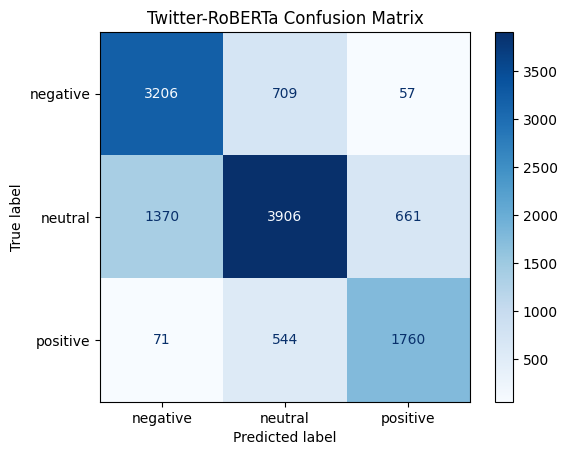

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    labels=["negative", "neutral", "positive"],
    cmap="Blues"
)

plt.title("Twitter-RoBERTa Confusion Matrix")
plt.show()
# The model correctly classified most tweets, but neutral sentiment was the most challenging class, especially when misclassified as negative. Direct confusion between negative and positive was relatively low.

In [ ]:
from transformers import pipeline

gpt2_sentiment = pipeline(
    "text-classification",
    model="LYTinn/gpt2-finetuning-sentiment-model-3000-samples",
    device=0
)

config.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  510MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: LYTinn/gpt2-finetuning-sentiment-model-3000-samples
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors: reconstructing file:   0%|          |  0.00B /  510MB            

model.safetensors: downloading bytes:           |  0.00B            

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained(
    "LYTinn/gpt2-finetuning-sentiment-model-3000-samples"
)

print(config.id2label)
print(config.label2id)
# The model configuration only provides generic labels (LABEL_0 and LABEL_1) without specifying their sentiment meaning. Therefore, the mapping between these labels and positive/negative sentiment must be verified before the model can be reliably evaluated.

{0: 'LABEL_0', 1: 'LABEL_1'}
{'LABEL_0': 0, 'LABEL_1': 1}


In [ ]:
examples = [
    "I absolutely love this movie. It is amazing!",
    "This movie is excellent and wonderful.",
    "I really enjoyed this film.",
    "I absolutely hate this movie. It is horrible!",
    "This movie is terrible and disappointing.",
    "This is the worst film I have ever seen."
]

for text in examples:
    print(text)
    print(gpt2_sentiment(text))
    print()

I absolutely love this movie. It is amazing!
[{'label': 'LABEL_1', 'score': 0.8859172463417053}]

This movie is excellent and wonderful.
[{'label': 'LABEL_0', 'score': 0.9469677805900574}]

I really enjoyed this film.
[{'label': 'LABEL_0', 'score': 0.9219717383384705}]

I absolutely hate this movie. It is horrible!
[{'label': 'LABEL_1', 'score': 0.6005716323852539}]

This movie is terrible and disappointing.
[{'label': 'LABEL_0', 'score': 0.6058025360107422}]

This is the worst film I have ever seen.
[{'label': 'LABEL_0', 'score': 0.9999924898147583}]



In [ ]:
binary_test = test_df[
    test_df["sentiment"].isin(
        ["negative", "positive"]
    )
].copy()

In [ ]:
binary_val = val_df[
    val_df["sentiment"].isin(
        ["negative", "positive"]
    )
].copy()

In [ ]:
binary_val["clean_text"] = binary_val["text"].apply(preprocess_tweet)

binary_test["clean_text"] = binary_test["text"].apply(preprocess_tweet)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch

model_name = "LYTinn/gpt2-finetuning-sentiment-model-3000-samples"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name
)

# Tambahkan PAD token baru
tokenizer.add_special_tokens({
    "pad_token": "[PAD]"
})

# Sesuaikan ukuran embedding model
model.resize_token_embeddings(len(tokenizer))

# Beritahu model ID padding
model.config.pad_token_id = tokenizer.pad_token_id

device = 0 if torch.cuda.is_available() else -1

gpt2_sentiment = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device
)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: LYTinn/gpt2-finetuning-sentiment-model-3000-samples
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
print("PAD token:", gpt2_sentiment.tokenizer.pad_token)
print("PAD token ID:", gpt2_sentiment.tokenizer.pad_token_id)
print("Model PAD ID:", gpt2_sentiment.model.config.pad_token_id)

PAD token: [PAD]
PAD token ID: 0
Model PAD ID: 0


In [ ]:
val_predictions = gpt2_sentiment(
    binary_val["clean_text"].tolist(),
    batch_size=32,
    truncation=True,
    max_length=128,
    padding=True
)

In [ ]:
binary_val["gpt2_raw"] = [
    pred["label"]
    for pred in val_predictions
]

In [ ]:
binary_val[
    ["text", "sentiment", "gpt2_raw"]
].head(10)

,text,sentiment,gpt2_raw
1,"""National hot dog day, national tequila day, t...",positive,LABEL_0
2,When girls become bandwagon fans of the Packer...,negative,LABEL_0
6,#US 1st Lady Michelle Obama speaking at the 20...,positive,LABEL_0
7,Omg this show is so predictable even for the 3...,negative,LABEL_1
8,"""What a round by Paul Dunne, good luck tomorro...",positive,LABEL_0
10,"@user so the thing next Thursday isn't free, y...",negative,LABEL_0
11,Can't wait for tomorrow at 9 pm! Chelsea v cry...,positive,LABEL_1
14,F*** the hurricane party this Tues santosparty...,negative,LABEL_1
15,"""Thank you @user for the message. I'm very pro...",positive,LABEL_1
16,Tom Brady is locked for Thursday. Let the seas...,positive,LABEL_1


In [ ]:
from sklearn.metrics import accuracy_score

mapping_1 = {
    "LABEL_0": "negative",
    "LABEL_1": "positive"
}

mapping_2 = {
    "LABEL_0": "positive",
    "LABEL_1": "negative"
}

pred_1 = binary_val["gpt2_raw"].map(mapping_1)
pred_2 = binary_val["gpt2_raw"].map(mapping_2)

acc_1 = accuracy_score(binary_val["sentiment"], pred_1)
acc_2 = accuracy_score(binary_val["sentiment"], pred_2)

print("Mapping 1 accuracy:", acc_1)
print("Mapping 2 accuracy:", acc_2)

Mapping 1 accuracy: 0.5596816976127321
Mapping 2 accuracy: 0.4403183023872679


In [ ]:
label_map_gpt2 = {
    "LABEL_0": "negative",
    "LABEL_1": "positive"
}

In [ ]:
test_predictions = gpt2_sentiment(
    binary_test["clean_text"].tolist(),
    batch_size=32,
    truncation=True,
    max_length=128,
    padding=True
)

In [ ]:
binary_test["gpt2_raw"] = [
    pred["label"]
    for pred in test_predictions
]

In [ ]:
binary_test["gpt2_pred"] = (
    binary_test["gpt2_raw"]
    .map(label_map_gpt2)
)

In [ ]:
binary_test[
    ["text", "sentiment", "gpt2_raw", "gpt2_pred"]
].head(10)

,text,sentiment,gpt2_raw,gpt2_pred
3,I think I may be finally in with the in crowd ...,positive,LABEL_1,positive
4,"@user Wow,first Hugo Chavez and now Fidel Cast...",negative,LABEL_1,positive
7,Twitter's #ThankYouObama Shows Heartfelt Grati...,positive,LABEL_0,negative
9,@user @user @user @user @user @user take away ...,negative,LABEL_1,positive
12,#onedirection #harrystyles cute little dance 😉,positive,LABEL_0,negative
13,"When Ryan privatizes SS, Medicare, Medicaid, &...",negative,LABEL_1,positive
14,Swampbitch Nasty Pelosi loves yelling 'Fire' ...,negative,LABEL_1,positive
21,@user Going to see #FantasticBeasts this after...,positive,LABEL_1,positive
26,The left has really gone Full retard haven't t...,negative,LABEL_0,negative
33,Can't wait to try this - Google Earth VR - thi...,positive,LABEL_0,negative


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    recall_score
)

y_true = binary_test["sentiment"]
y_pred = binary_test["gpt2_pred"]

print("Accuracy:",
      accuracy_score(y_true, y_pred))

print("Macro F1:",
      f1_score(y_true, y_pred, average="macro"))

print("Macro Recall:",
      recall_score(y_true, y_pred, average="macro"))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred
    )
)

Accuracy: 0.5360012604380022
Macro F1: 0.526087310924977
Macro Recall: 0.5333770074733661

Classification Report:
              precision    recall  f1-score   support

    negative       0.66      0.54      0.59      3972
    positive       0.41      0.52      0.46      2375

    accuracy                           0.54      6347
   macro avg       0.53      0.53      0.53      6347
weighted avg       0.56      0.54      0.54      6347



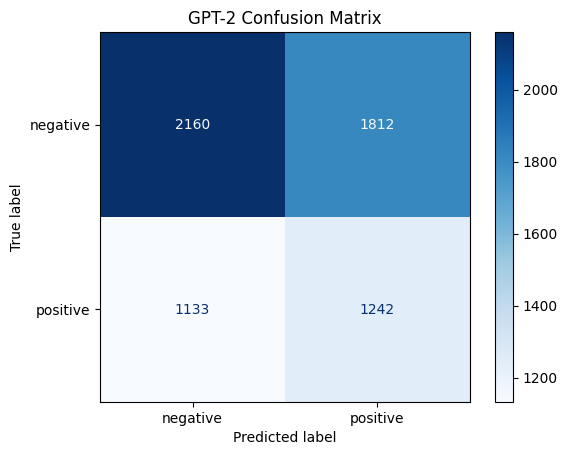

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    labels=["negative", "positive"],
    cmap="Blues"
)

plt.title("GPT-2 Confusion Matrix")
plt.show()
# The relatively low performance indicates that the GPT-2 model does not generalize well to the TweetEval Twitter dataset.

In [ ]:
roberta_binary_outputs = roberta(
    binary_test["clean_text"].tolist(),
    batch_size=64,
    truncation=True,
    max_length=128,
    top_k=None
)

In [ ]:
roberta_binary_outputs[0]

[{'label': 'positive', 'score': 0.7859699726104736},
 {'label': 'neutral', 'score': 0.2103567123413086},
 {'label': 'negative', 'score': 0.003673277562484145}]

In [ ]:
def get_binary_roberta(scores):
    score_dict = {
        item["label"].lower(): item["score"]
        for item in scores
    }

    if score_dict["negative"] >= score_dict["positive"]:
        return "negative"
    else:
        return "positive"

In [ ]:
binary_test["roberta_binary_pred"] = [
    get_binary_roberta(scores)
    for scores in roberta_binary_outputs
]

In [ ]:
binary_test[
    ["text", "sentiment", "gpt2_pred", "roberta_binary_pred"]
].head(10)

,text,sentiment,gpt2_pred,roberta_binary_pred
3,I think I may be finally in with the in crowd ...,positive,positive,positive
4,"@user Wow,first Hugo Chavez and now Fidel Cast...",negative,positive,negative
7,Twitter's #ThankYouObama Shows Heartfelt Grati...,positive,negative,positive
9,@user @user @user @user @user @user take away ...,negative,positive,negative
12,#onedirection #harrystyles cute little dance 😉,positive,negative,positive
13,"When Ryan privatizes SS, Medicare, Medicaid, &...",negative,positive,negative
14,Swampbitch Nasty Pelosi loves yelling 'Fire' ...,negative,positive,negative
21,@user Going to see #FantasticBeasts this after...,positive,positive,positive
26,The left has really gone Full retard haven't t...,negative,negative,negative
33,Can't wait to try this - Google Earth VR - thi...,positive,negative,positive


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report
)

y_true = binary_test["sentiment"]
y_pred_roberta = binary_test["roberta_binary_pred"]

roberta_accuracy = accuracy_score(
    y_true,
    y_pred_roberta
)

roberta_f1 = f1_score(
    y_true,
    y_pred_roberta,
    average="macro"
)

roberta_recall = recall_score(
    y_true,
    y_pred_roberta,
    average="macro"
)

print("Accuracy:", roberta_accuracy)
print("Macro F1:", roberta_f1)
print("Macro Recall:", roberta_recall)

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred_roberta
    )
)

Accuracy: 0.9462738301559792
Macro F1: 0.942810097037712
Macro Recall: 0.9441238140668893

Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.95      0.96      3972
    positive       0.92      0.94      0.93      2375

    accuracy                           0.95      6347
   macro avg       0.94      0.94      0.94      6347
weighted avg       0.95      0.95      0.95      6347



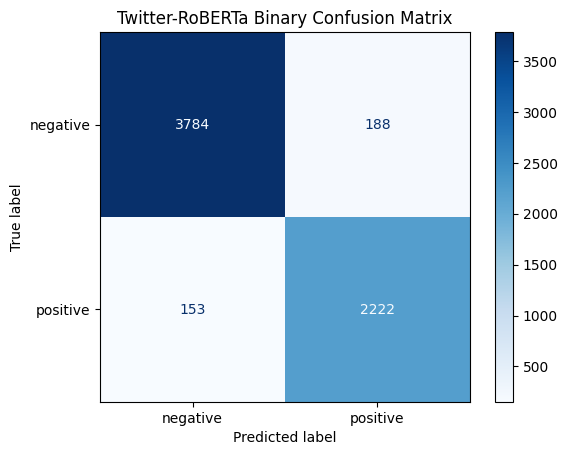

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred_roberta,
    labels=["negative", "positive"],
    cmap="Blues"
)

plt.title("Twitter-RoBERTa Binary Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "GPT-2",
        "Twitter-RoBERTa"
    ],
    "Accuracy": [
        0.5360012604380022,
        roberta_accuracy
    ],
    "Macro F1": [
        0.526087310924977,
        roberta_f1
    ],
    "Macro Recall": [
        0.5333770074733661,
        roberta_recall
    ]
})

comparison
# Twitter-RoBERTa clearly outperformed GPT-2 on the same binary test set, achieving around 94% across all metrics compared with around 53% for GPT-2. This suggests that Twitter-RoBERTa is substantially more suitable for Twitter sentiment analysis.

,Model,Accuracy,Macro F1,Macro Recall
0,GPT-2,0.536001,0.526087,0.533377
1,Twitter-RoBERTa,0.946274,0.942810,0.944124


In [ ]:
import pandas as pd

marketplace_data = [
    ["The product arrived quickly and works perfectly.", "positive", "product_review"],
    ["Very disappointed, the item was damaged when it arrived.", "negative", "product_review"],
    ["The seller responded quickly and was very helpful.", "positive", "seller_review"],
    ["The seller never replied to my messages.", "negative", "seller_review"],
    ["Delivery was faster than expected.", "positive", "delivery"],
    ["My order arrived two weeks late.", "negative", "delivery"],
    ["The refund process was simple and fast.", "positive", "refund"],
    ["I still haven't received my refund after three weeks.", "negative", "refund"],
    ["The checkout process was smooth and easy.", "positive", "platform"],
    ["The payment keeps failing every time I try to order.", "negative", "platform"],
    ["Great quality for the price.", "positive", "product_review"],
    ["Waste of money, the product stopped working after one day.", "negative", "product_review"],
    ["Customer service solved my problem immediately.", "positive", "customer_service"],
    ["Customer service was useless and did not solve anything.", "negative", "customer_service"],
    ["I thought this would be terrible, but it is actually amazing.", "positive", "negation"],
    ["Looks good in the pictures, but the actual product is awful.", "negative", "mixed_sentiment"],
    ["Thanks for sending me a broken product. Great service.", "negative", "sarcasm"],
    ["I was worried about ordering here, but everything went perfectly.", "positive", "mixed_sentiment"]
]

marketplace_df = pd.DataFrame(
    marketplace_data,
    columns=["text", "sentiment", "category"]
)

marketplace_df

,text,sentiment,category
0,The product arrived quickly and works perfectly.,positive,product_review
1,"Very disappointed, the item was damaged when i...",negative,product_review
2,The seller responded quickly and was very help...,positive,seller_review
3,The seller never replied to my messages.,negative,seller_review
4,Delivery was faster than expected.,positive,delivery
5,My order arrived two weeks late.,negative,delivery
6,The refund process was simple and fast.,positive,refund
7,I still haven't received my refund after three...,negative,refund
8,The checkout process was smooth and easy.,positive,platform
9,The payment keeps failing every time I try to ...,negative,platform


In [ ]:
!pip install -q transformers torch scikit-learn

In [ ]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

bertweet = pipeline(
    "text-classification",
    model="finiteautomata/bertweet-base-sentiment-analysis",
    device=device
)

print("Device:", "GPU" if device == 0 else "CPU")

config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  540MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/338 [00:00<?, ?B/s]

...

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Device: GPU


In [ ]:
print(bertweet.model.config.id2label)
print(bertweet.model.config.label2id)

{0: 'NEG', 1: 'NEU', 2: 'POS'}
{'NEG': 0, 'NEU': 1, 'POS': 2}


In [ ]:
!git clone https://github.com/cardiffnlp/tweeteval.git

Cloning into 'tweeteval'...
remote: Enumerating objects: 370, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 370 (delta 13), reused 3 (delta 1), pack-reused 354 (from 1)
Receiving objects: 100% (370/370), 8.49 MiB | 19.59 MiB/s, done.
Resolving deltas: 100% (122/122), done.


In [ ]:
from pathlib import Path

DATA_PATH = Path("/content/tweeteval/datasets/sentiment")

print("TweetEval dataset exists:", DATA_PATH.exists())

TweetEval dataset exists: True


In [ ]:
import pandas as pd

PATH = "/content/tweeteval/datasets/sentiment"

label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

def load_split(split):
    with open(
        f"{PATH}/{split}_text.txt",
        "r",
        encoding="utf-8"
    ) as f:
        texts = [
            line.rstrip("\n")
            for line in f
        ]

    with open(
        f"{PATH}/{split}_labels.txt",
        "r",
        encoding="utf-8"
    ) as f:
        labels = [
            int(line.strip())
            for line in f
        ]

    df = pd.DataFrame({
        "text": texts,
        "label": labels
    })

    df["sentiment"] = df["label"].map(label_map)

    return df


train_df = load_split("train")
val_df = load_split("val")
test_df = load_split("test")

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)

Train      : (45615, 3)
Validation : (2000, 3)
Test       : (12284, 3)


In [ ]:
import pandas as pd
from pathlib import Path

# Check whether TweetEval dataset still exists
DATA_PATH = Path("/content/tweeteval/datasets/sentiment")

print("TweetEval dataset exists:", DATA_PATH.exists())

TweetEval dataset exists: False


In [ ]:
def preprocess_tweet(text):
    new_text = []

    for token in text.split():

        if token.startswith("@") and len(token) > 1:
            token = "@user"

        elif token.startswith("http"):
            token = "http"

        new_text.append(token)

    return " ".join(new_text)


test_df["clean_text"] = test_df["text"].apply(
    preprocess_tweet
)

print(
    test_df[
        ["text", "clean_text", "sentiment"]
    ].head()
)

                                                text  \
0  @user @user what do these '1/2 naked pics' hav...   
1  OH: “I had a blue penis while I was this” [pla...   
2  @user @user That's coming, but I think the vic...   
3  I think I may be finally in with the in crowd ...   
4  @user Wow,first Hugo Chavez and now Fidel Cast...   

                                          clean_text sentiment  
0  @user @user what do these '1/2 naked pics' hav...   neutral  
1  OH: “I had a blue penis while I was this” [pla...   neutral  
2  @user @user That's coming, but I think the vic...   neutral  
3  I think I may be finally in with the in crowd ...  positive  
4  @user Wow,first Hugo Chavez and now Fidel Cast...  negative  


In [ ]:
print("Test samples:", len(test_df))

print(
    "Sentiment classes:",
    test_df["sentiment"].unique()
)

print(
    "clean_text exists:",
    "clean_text" in test_df.columns
)

Test samples: 12284
Sentiment classes: ['neutral' 'positive' 'negative']
clean_text exists: True


In [ ]:
if "clean_text" not in test_df.columns:
    test_df["clean_text"] = test_df["text"].apply(
        preprocess_tweet
    )

print(test_df[["text", "clean_text"]].head())

                                                text  \
0  @user @user what do these '1/2 naked pics' hav...   
1  OH: “I had a blue penis while I was this” [pla...   
2  @user @user That's coming, but I think the vic...   
3  I think I may be finally in with the in crowd ...   
4  @user Wow,first Hugo Chavez and now Fidel Cast...   

                                          clean_text  
0  @user @user what do these '1/2 naked pics' hav...  
1  OH: “I had a blue penis while I was this” [pla...  
2  @user @user That's coming, but I think the vic...  
3  I think I may be finally in with the in crowd ...  
4  @user Wow,first Hugo Chavez and now Fidel Cast...  


In [ ]:
texts = test_df["clean_text"].tolist()

bertweet_predictions = bertweet(
    texts,
    batch_size=32,
    truncation=True,
    max_length=128
)

print("Number of test samples :", len(test_df))
print("Number of predictions  :", len(bertweet_predictions))

print("\nFirst 5 raw predictions:")
print(bertweet_predictions[:5])

Number of test samples : 12284
Number of predictions  : 12284

First 5 raw predictions:
[{'label': 'NEG', 'score': 0.8125519156455994}, {'label': 'NEU', 'score': 0.9567384123802185}, {'label': 'NEG', 'score': 0.659974992275238}, {'label': 'POS', 'score': 0.8269330263137817}, {'label': 'NEU', 'score': 0.529639720916748}]


In [ ]:
bertweet_label_map = {
    "NEG": "negative",
    "NEU": "neutral",
    "POS": "positive"
}

test_df["bertweet_raw"] = [
    pred["label"]
    for pred in bertweet_predictions
]

test_df["bertweet_pred"] = (
    test_df["bertweet_raw"]
    .map(bertweet_label_map)
)

print(
    test_df[
        [
            "text",
            "sentiment",
            "bertweet_raw",
            "bertweet_pred"
        ]
    ].head(10)
)

                                                text sentiment bertweet_raw  \
0  @user @user what do these '1/2 naked pics' hav...   neutral          NEG   
1  OH: “I had a blue penis while I was this” [pla...   neutral          NEU   
2  @user @user That's coming, but I think the vic...   neutral          NEG   
3  I think I may be finally in with the in crowd ...  positive          POS   
4  @user Wow,first Hugo Chavez and now Fidel Cast...  negative          NEU   
5  Savchenko now Saakashvili took drug test live ...   neutral          NEG   
6           How many more days until opening day? 😩    neutral          NEU   
7  Twitter's #ThankYouObama Shows Heartfelt Grati...  positive          POS   
8  All CSG and Fracking all around Australia is t...   neutral          NEG   
9  @user @user @user @user @user @user take away ...  negative          NEU   

  bertweet_pred  
0      negative  
1       neutral  
2      negative  
3      positive  
4       neutral  
5      negative  
6   

In [ ]:
print(
    "Missing mapped predictions:",
    test_df["bertweet_pred"].isna().sum()
)

print("\nPredicted class distribution:")
print(
    test_df["bertweet_pred"].value_counts()
)

Missing mapped predictions: 0

Predicted class distribution:
bertweet_pred
neutral     5320
negative    4456
positive    2508
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    recall_score
)

y_true = test_df["sentiment"]
y_pred_bertweet = test_df["bertweet_pred"]

bertweet_accuracy = accuracy_score(
    y_true,
    y_pred_bertweet
)

bertweet_f1 = f1_score(
    y_true,
    y_pred_bertweet,
    average="macro"
)

bertweet_recall = recall_score(
    y_true,
    y_pred_bertweet,
    average="macro"
)

print("BERTweet Results")
print("-----------------")

print("Accuracy     :", bertweet_accuracy)
print("Macro F1     :", bertweet_f1)
print("Macro Recall :", bertweet_recall)

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred_bertweet
    )
)

BERTweet Results
-----------------
Accuracy     : 0.7206121784435038
Macro F1     : 0.7206540806093674
Macro Recall : 0.7302490511423639

Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.79      0.75      3972
     neutral       0.75      0.67      0.71      5937
    positive       0.69      0.73      0.71      2375

    accuracy                           0.72     12284
   macro avg       0.71      0.73      0.72     12284
weighted avg       0.72      0.72      0.72     12284



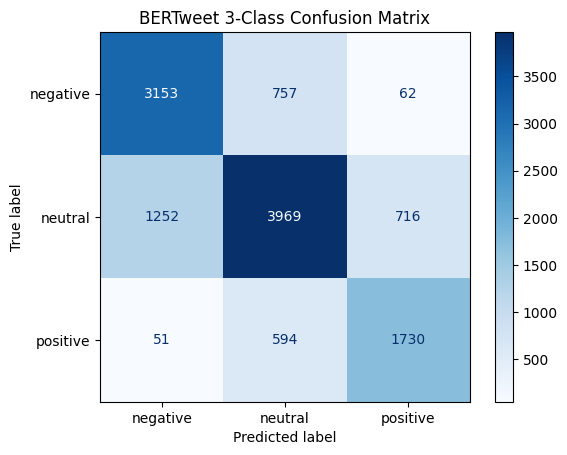

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred_bertweet,
    labels=[
        "negative",
        "neutral",
        "positive"
    ],
    cmap="Blues"
)

plt.title(
    "BERTweet 3-Class Confusion Matrix"
)

plt.show()

In [ ]:
from sklearn.metrics import precision_score

# BERTweet Macro Precision
bertweet_precision = precision_score(
    y_true,
    y_pred_bertweet,
    average="macro"
)

print("BERTweet Macro Precision:", bertweet_precision)

BERTweet Macro Precision: 0.7144768577774342


In [ ]:
from sklearn.metrics import precision_score

# BERTweet exact Macro Precision
bertweet_precision = precision_score(
    y_true,
    y_pred_bertweet,
    average="macro"
)

# Twitter-RoBERTa Macro Precision
# Taken from the previous 3-class classification report
roberta_precision = 0.72

print("Twitter-RoBERTa Macro Precision:", roberta_precision)
print("BERTweet Macro Precision       :", bertweet_precision)

Twitter-RoBERTa Macro Precision: 0.72
BERTweet Macro Precision       : 0.7144768577774342


In [ ]:
import pandas as pd

comparison_3class = pd.DataFrame({
    "Model": [
        "Twitter-RoBERTa",
        "BERTweet"
    ],

    "Accuracy": [
        0.7222403126017584,
        bertweet_accuracy
    ],

    "Macro Precision": [
        roberta_precision,
        bertweet_precision
    ],

    "Macro F1": [
        0.7244332814398557,
        bertweet_f1
    ],

    "Macro Recall": [
        0.7353702387640677,
        bertweet_recall
    ]
})

comparison_3class

,Model,Accuracy,Macro Precision,Macro F1,Macro Recall
0,Twitter-RoBERTa,0.722240,0.720000,0.724433,0.735370
1,BERTweet,0.720612,0.714477,0.720654,0.730249


In [ ]:
binary_test_bertweet = test_df[
    test_df["sentiment"].isin(
        ["negative", "positive"]
    )
].copy()

print(
    binary_test_bertweet["sentiment"].value_counts()
)

print(
    "Total binary test samples:",
    len(binary_test_bertweet)
)

sentiment
negative    3972
positive    2375
Name: count, dtype: int64
Total binary test samples: 6347


In [ ]:
if "clean_text" not in binary_test_bertweet.columns:
    binary_test_bertweet["clean_text"] = (
        binary_test_bertweet["text"]
        .apply(preprocess_tweet)
    )

print(
    binary_test_bertweet[
        ["text", "clean_text", "sentiment"]
    ].head()
)

                                                 text  \
3   I think I may be finally in with the in crowd ...   
4   @user Wow,first Hugo Chavez and now Fidel Cast...   
7   Twitter's #ThankYouObama Shows Heartfelt Grati...   
9   @user @user @user @user @user @user take away ...   
12    #onedirection #harrystyles cute little dance 😉    

                                           clean_text sentiment  
3   I think I may be finally in with the in crowd ...  positive  
4   @user Wow,first Hugo Chavez and now Fidel Cast...  negative  
7   Twitter's #ThankYouObama Shows Heartfelt Grati...  positive  
9   @user @user @user @user @user @user take away ...  negative  
12     #onedirection #harrystyles cute little dance 😉  positive  


In [ ]:
bertweet_binary_outputs = bertweet(
    binary_test_bertweet["clean_text"].tolist(),
    batch_size=32,
    truncation=True,
    max_length=128,
    top_k=None
)

print(
    "Number of test samples :",
    len(binary_test_bertweet)
)

print(
    "Number of predictions  :",
    len(bertweet_binary_outputs)
)

print("\nFirst raw prediction:")
print(bertweet_binary_outputs[0])

Number of test samples : 6347
Number of predictions  : 6347

First raw prediction:
[{'label': 'POS', 'score': 0.8269330263137817}, {'label': 'NEU', 'score': 0.17138375341892242}, {'label': 'NEG', 'score': 0.001683237962424755}]


In [ ]:
def get_binary_bertweet(scores):

    score_dict = {
        item["label"].upper(): item["score"]
        for item in scores
    }

    if score_dict["NEG"] >= score_dict["POS"]:
        return "negative"

    return "positive"


binary_test_bertweet["bertweet_binary_pred"] = [
    get_binary_bertweet(scores)
    for scores in bertweet_binary_outputs
]

In [ ]:
print(
    binary_test_bertweet[
        [
            "text",
            "sentiment",
            "bertweet_binary_pred"
        ]
    ].head(10)
)
print("Predicted class distribution:")

print(
    binary_test_bertweet[
        "bertweet_binary_pred"
    ].value_counts()
)

                                                 text sentiment  \
3   I think I may be finally in with the in crowd ...  positive   
4   @user Wow,first Hugo Chavez and now Fidel Cast...  negative   
7   Twitter's #ThankYouObama Shows Heartfelt Grati...  positive   
9   @user @user @user @user @user @user take away ...  negative   
12    #onedirection #harrystyles cute little dance 😉   positive   
13  When Ryan privatizes SS, Medicare, Medicaid, &...  negative   
14  Swampbitch Nasty Pelosi  loves yelling 'Fire' ...  negative   
21  @user Going to see #FantasticBeasts this after...  positive   
26  The left has really gone Full retard haven't t...  negative   
33  Can't wait to try this - Google Earth VR - thi...  positive   

   bertweet_binary_pred  
3              positive  
4              negative  
7              positive  
9              positive  
12             positive  
13             negative  
14             negative  
21             positive  
26             negative  
33

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    recall_score,
    classification_report
)

y_true_binary = (
    binary_test_bertweet["sentiment"]
)

y_pred_bertweet_binary = (
    binary_test_bertweet[
        "bertweet_binary_pred"
    ]
)

bertweet_binary_accuracy = accuracy_score(
    y_true_binary,
    y_pred_bertweet_binary
)

bertweet_binary_precision = precision_score(
    y_true_binary,
    y_pred_bertweet_binary,
    average="macro"
)

bertweet_binary_f1 = f1_score(
    y_true_binary,
    y_pred_bertweet_binary,
    average="macro"
)

bertweet_binary_recall = recall_score(
    y_true_binary,
    y_pred_bertweet_binary,
    average="macro"
)

print("BERTweet Binary Results")
print("------------------------")

print(
    "Accuracy        :",
    bertweet_binary_accuracy
)

print(
    "Macro Precision :",
    bertweet_binary_precision
)

print(
    "Macro F1        :",
    bertweet_binary_f1
)

print(
    "Macro Recall    :",
    bertweet_binary_recall
)

print("\nClassification Report:")

print(
    classification_report(
        y_true_binary,
        y_pred_bertweet_binary
    )
)

BERTweet Binary Results
------------------------
Accuracy        : 0.9420198518985348
Macro Precision : 0.9350869561958319
Macro F1        : 0.9386812355490981
Macro Recall    : 0.943010441511634

Classification Report:
              precision    recall  f1-score   support

    negative       0.97      0.94      0.95      3972
    positive       0.90      0.95      0.92      2375

    accuracy                           0.94      6347
   macro avg       0.94      0.94      0.94      6347
weighted avg       0.94      0.94      0.94      6347



Text(0.5, 1.0, 'BERTweet Binary Confusion Matrix')

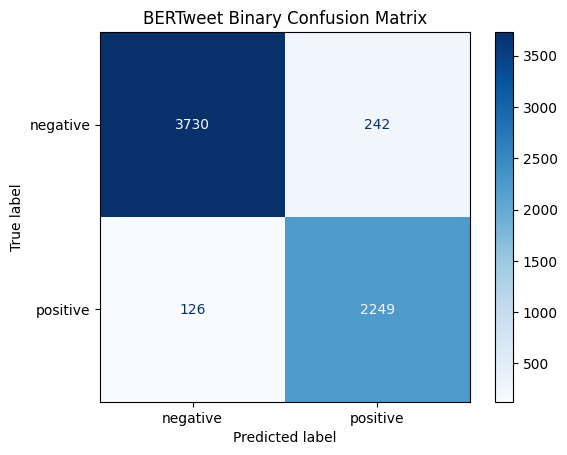

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true_binary,
    y_pred_bertweet_binary,
    labels=[
        "negative",
        "positive"
    ],
    cmap="Blues"
)

plt.title(
    "BERTweet Binary Confusion Matrix"
)


In [ ]:
import pandas as pd

comparison_binary = pd.DataFrame({
    "Model": [
        "GPT-2",
        "Twitter-RoBERTa",
        "BERTweet"
    ],

    "Accuracy": [
        0.5360012604380022,
        0.9462738301559792,
        bertweet_binary_accuracy
    ],

    "Macro F1": [
        0.526087310924977,
        0.942810097037712,
        bertweet_binary_f1
    ],

    "Macro Recall": [
        0.5333770074733661,
        0.9441238140668893,
        bertweet_binary_recall
    ]
})

comparison_binary

,Model,Accuracy,Macro F1,Macro Recall
0,GPT-2,0.536001,0.526087,0.533377
1,Twitter-RoBERTa,0.946274,0.942810,0.944124
2,BERTweet,0.942020,0.938681,0.943010


In [ ]:
from sklearn.metrics import precision_score

bertweet_binary_precision = precision_score(
    y_true_binary,
    y_pred_bertweet_binary,
    average="macro"
)

print(
    "BERTweet Macro Precision:",
    bertweet_binary_precision
)
gpt2_binary_precision = (0.66 + 0.41) / 2
roberta_binary_precision = (0.96 + 0.92) / 2

print("GPT-2 Macro Precision           :", gpt2_binary_precision)
print("Twitter-RoBERTa Macro Precision :", roberta_binary_precision)
print("BERTweet Macro Precision        :", bertweet_binary_precision)

BERTweet Macro Precision: 0.9350869561958319
GPT-2 Macro Precision           : 0.535
Twitter-RoBERTa Macro Precision : 0.94
BERTweet Macro Precision        : 0.9350869561958319


In [ ]:
import pandas as pd

comparison_binary = pd.DataFrame({
    "Model": [
        "GPT-2",
        "Twitter-RoBERTa",
        "BERTweet"
    ],

    "Accuracy": [
        0.5360012604380022,
        0.9462738301559792,
        bertweet_binary_accuracy
    ],

    "Macro Precision": [
        gpt2_binary_precision,
        roberta_binary_precision,
        bertweet_binary_precision
    ],

    "Macro F1": [
        0.526087310924977,
        0.942810097037712,
        bertweet_binary_f1
    ],

    "Macro Recall": [
        0.5333770074733661,
        0.9441238140668893,
        bertweet_binary_recall
    ]
})

comparison_binary

,Model,Accuracy,Macro Precision,Macro F1,Macro Recall
0,GPT-2,0.536001,0.535000,0.526087,0.533377
1,Twitter-RoBERTa,0.946274,0.940000,0.942810,0.944124
2,BERTweet,0.942020,0.935087,0.938681,0.943010


In [ ]:
binary_test_distilbert = test_df[
    test_df["sentiment"].isin(
        ["negative", "positive"]
    )
].copy()

print(
    binary_test_distilbert["sentiment"].value_counts()
)

print(
    "Total binary test samples:",
    len(binary_test_distilbert)
)

sentiment
negative    3972
positive    2375
Name: count, dtype: int64
Total binary test samples: 6347


In [ ]:
if "clean_text" not in binary_test_distilbert.columns:
    binary_test_distilbert["clean_text"] = (
        binary_test_distilbert["text"]
        .apply(preprocess_tweet)
    )

print(
    binary_test_distilbert[
        [
            "text",
            "clean_text",
            "sentiment"
        ]
    ].head()
)

                                                 text  \
3   I think I may be finally in with the in crowd ...   
4   @user Wow,first Hugo Chavez and now Fidel Cast...   
7   Twitter's #ThankYouObama Shows Heartfelt Grati...   
9   @user @user @user @user @user @user take away ...   
12    #onedirection #harrystyles cute little dance 😉    

                                           clean_text sentiment  
3   I think I may be finally in with the in crowd ...  positive  
4   @user Wow,first Hugo Chavez and now Fidel Cast...  negative  
7   Twitter's #ThankYouObama Shows Heartfelt Grati...  positive  
9   @user @user @user @user @user @user take away ...  negative  
12     #onedirection #harrystyles cute little dance 😉  positive  


In [ ]:
import torch

from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

distilbert = pipeline(
    "text-classification",
    model=(
        "distilbert/"
        "distilbert-base-uncased-finetuned-sst-2-english"
    ),
    device=device
)

print(
    "Device:",
    "GPU" if device == 0 else "CPU"
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device: GPU


In [ ]:
print(
    distilbert.model.config.id2label
)

print(
    distilbert.model.config.label2id
)

{0: 'NEGATIVE', 1: 'POSITIVE'}
{'NEGATIVE': 0, 'POSITIVE': 1}


In [ ]:
distilbert_predictions = distilbert(
    binary_test_distilbert[
        "clean_text"
    ].tolist(),

    batch_size=32,
    truncation=True,
    max_length=128
)

print(
    "Number of test samples :",
    len(binary_test_distilbert)
)

print(
    "Number of predictions  :",
    len(distilbert_predictions)
)

print(
    "\nFirst 5 raw predictions:"
)

print(
    distilbert_predictions[:5]
)

Number of test samples : 6347
Number of predictions  : 6347

First 5 raw predictions:
[{'label': 'POSITIVE', 'score': 0.9938226938247681}, {'label': 'NEGATIVE', 'score': 0.9919803142547607}, {'label': 'POSITIVE', 'score': 0.9997603297233582}, {'label': 'POSITIVE', 'score': 0.9980989098548889}, {'label': 'POSITIVE', 'score': 0.9970322847366333}]


In [ ]:
binary_test_distilbert[
    "distilbert_raw"
] = [
    pred["label"]
    for pred in distilbert_predictions
]

binary_test_distilbert[
    "distilbert_pred"
] = [
    pred["label"].lower()
    for pred in distilbert_predictions
]

print(
    binary_test_distilbert[
        [
            "text",
            "sentiment",
            "distilbert_raw",
            "distilbert_pred"
        ]
    ].head(10)
)

                                                 text sentiment  \
3   I think I may be finally in with the in crowd ...  positive   
4   @user Wow,first Hugo Chavez and now Fidel Cast...  negative   
7   Twitter's #ThankYouObama Shows Heartfelt Grati...  positive   
9   @user @user @user @user @user @user take away ...  negative   
12    #onedirection #harrystyles cute little dance 😉   positive   
13  When Ryan privatizes SS, Medicare, Medicaid, &...  negative   
14  Swampbitch Nasty Pelosi  loves yelling 'Fire' ...  negative   
21  @user Going to see #FantasticBeasts this after...  positive   
26  The left has really gone Full retard haven't t...  negative   
33  Can't wait to try this - Google Earth VR - thi...  positive   

   distilbert_raw distilbert_pred  
3        POSITIVE        positive  
4        NEGATIVE        negative  
7        POSITIVE        positive  
9        POSITIVE        positive  
12       POSITIVE        positive  
13       POSITIVE        positive  
14       N

In [ ]:
print(
    "Missing predictions:",
    binary_test_distilbert[
        "distilbert_pred"
    ].isna().sum()
)

print(
    "\nPredicted class distribution:"
)

print(
    binary_test_distilbert[
        "distilbert_pred"
    ].value_counts()
)

Missing predictions: 0

Predicted class distribution:
distilbert_pred
negative    4323
positive    2024
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    recall_score,
    classification_report
)

y_true_distilbert = (
    binary_test_distilbert[
        "sentiment"
    ]
)

y_pred_distilbert = (
    binary_test_distilbert[
        "distilbert_pred"
    ]
)

distilbert_accuracy = accuracy_score(
    y_true_distilbert,
    y_pred_distilbert
)

distilbert_precision = precision_score(
    y_true_distilbert,
    y_pred_distilbert,
    average="macro"
)

distilbert_f1 = f1_score(
    y_true_distilbert,
    y_pred_distilbert,
    average="macro"
)

distilbert_recall = recall_score(
    y_true_distilbert,
    y_pred_distilbert,
    average="macro"
)

print("DistilBERT Binary Results")
print("-------------------------")

print(
    "Accuracy        :",
    distilbert_accuracy
)

print(
    "Macro Precision :",
    distilbert_precision
)

print(
    "Macro F1        :",
    distilbert_f1
)

print(
    "Macro Recall    :",
    distilbert_recall
)

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_true_distilbert,
        y_pred_distilbert
    )
)

DistilBERT Binary Results
-------------------------
Accuracy        : 0.8129825114227194
Macro Precision : 0.8077962666827585
Macro F1        : 0.7935338474235404
Macro Recall    : 0.7854869348598081

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.89      0.86      3972
    positive       0.79      0.68      0.73      2375

    accuracy                           0.81      6347
   macro avg       0.81      0.79      0.79      6347
weighted avg       0.81      0.81      0.81      6347



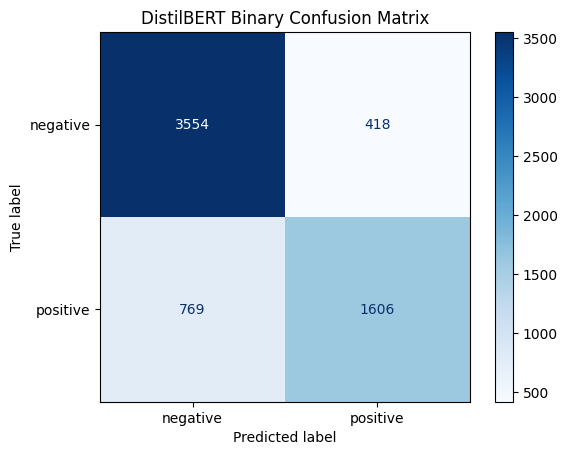

In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true_distilbert,
    y_pred_distilbert,
    labels=[
        "negative",
        "positive"
    ],
    cmap="Blues"
)

plt.title(
    "DistilBERT Binary Confusion Matrix"
)

plt.show()

In [ ]:
import pandas as pd

comparison_binary_models = pd.DataFrame({
    "Model": [
        "GPT-2",
        "DistilBERT"
    ],

    "Accuracy": [
        0.5360012604380022,
        distilbert_accuracy
    ],

    "Macro F1": [
        0.526087310924977,
        distilbert_f1
    ],

    "Macro Recall": [
        0.5333770074733661,
        distilbert_recall
    ]
})

comparison_binary_models

,Model,Accuracy,Macro F1,Macro Recall
0,GPT-2,0.536001,0.526087,0.533377
1,DistilBERT,0.812983,0.793534,0.785487


In [ ]:
import pandas as pd

comparison_binary = pd.DataFrame({
    "Model": [
        "GPT-2",
        "Twitter-RoBERTa",
        "BERTweet",
        "DistilBERT"
    ],

    "Accuracy": [
        0.5360012604380022,
        0.9462738301559792,
        bertweet_binary_accuracy,
        distilbert_accuracy
    ],

    "Macro Precision": [
        0.535,
        0.940,
        bertweet_binary_precision,
        distilbert_precision
    ],

    "Macro Recall": [
        0.5333770074733661,
        0.9441238140668893,
        bertweet_binary_recall,
        distilbert_recall
    ],

    "Macro F1": [
        0.526087310924977,
        0.942810097037712,
        bertweet_binary_f1,
        distilbert_f1
    ]
})

comparison_binary = comparison_binary.round(4)

print("Binary Sentiment Classification")
print("Negative / Positive")
print("TweetEval Binary Test Set: 6,347 tweets")
print()

display(comparison_binary)

Binary Sentiment Classification
Negative / Positive
TweetEval Binary Test Set: 6,347 tweets



,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,GPT-2,0.5360,0.5350,0.5334,0.5261
1,Twitter-RoBERTa,0.9463,0.9400,0.9441,0.9428
2,BERTweet,0.9420,0.9351,0.9430,0.9387
3,DistilBERT,0.8130,0.8078,0.7855,0.7935


In [ ]:
import pandas as pd

comparison_3class = pd.DataFrame({
    "Model": [
        "Twitter-RoBERTa",
        "BERTweet"
    ],

    "Accuracy": [
        0.7222403126017584,
        bertweet_accuracy
    ],

    "Macro Precision": [
        0.7200,
        bertweet_precision
    ],

    "Macro Recall": [
        0.7353702387640677,
        bertweet_recall
    ],

    "Macro F1": [
        0.7244332814398557,
        bertweet_f1
    ]
})

comparison_3class = comparison_3class.round(4)

print("3-Class Sentiment Classification")
print("Negative / Neutral / Positive")
print("TweetEval Test Set: 12,284 tweets")
print()

display(comparison_3class)

3-Class Sentiment Classification
Negative / Neutral / Positive
TweetEval Test Set: 12,284 tweets



,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Twitter-RoBERTa,0.7222,0.7200,0.7354,0.7244
1,BERTweet,0.7206,0.7145,0.7302,0.7207


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

GPT2_3CLASS_DIR = Path(
    "/content/drive/MyDrive/Sentiment_Project/gpt2_tweeteval_3class"
)

GPT2_3CLASS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(GPT2_3CLASS_DIR)

/content/drive/MyDrive/Sentiment_Project/gpt2_tweeteval_3class


In [ ]:
!pip install -q transformers datasets accelerate scikit-learn

In [ ]:
print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)

print(train_df["sentiment"].value_counts())

Train      : (45615, 3)
Validation : (2000, 3)
Test       : (12284, 6)
sentiment
neutral     20673
positive    17849
negative     7093
Name: count, dtype: int64


In [ ]:
def preprocess_tweet(text):
    new_text = []

    for token in text.split():

        if token.startswith("@") and len(token) > 1:
            token = "@user"

        elif token.startswith("http"):
            token = "http"

        new_text.append(token)

    return " ".join(new_text)


train_df["clean_text"] = train_df["text"].apply(
    preprocess_tweet
)

val_df["clean_text"] = val_df["text"].apply(
    preprocess_tweet
)

test_df["clean_text"] = test_df["text"].apply(
    preprocess_tweet
)

print(
    train_df[
        ["text", "clean_text", "sentiment"]
    ].head()
)

                                                text  \
0  "QT @user In the original draft of the 7th boo...   
1  "Ben Smith / Smith (concussion) remains out of...   
2  Sorry bout the stream last night I crashed out...   
3  Chase Headley's RBI double in the 8th inning o...   
4  @user Alciato: Bee will invest 150 million in ...   

                                          clean_text sentiment  
0  "QT @user In the original draft of the 7th boo...  positive  
1  "Ben Smith / Smith (concussion) remains out of...   neutral  
2  Sorry bout the stream last night I crashed out...   neutral  
3  Chase Headley's RBI double in the 8th inning o...   neutral  
4  @user Alciato: Bee will invest 150 million in ...  positive  


In [ ]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

print(label2id)
print(id2label)

{'negative': 0, 'neutral': 1, 'positive': 2}
{0: 'negative', 1: 'neutral', 2: 'positive'}


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[
        ["clean_text", "label"]
    ],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[
        ["clean_text", "label"]
    ],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[
        ["clean_text", "label"]
    ],
    preserve_index=False
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['clean_text', 'label'],
    num_rows: 45615
})
Dataset({
    features: ['clean_text', 'label'],
    num_rows: 2000
})
Dataset({
    features: ['clean_text', 'label'],
    num_rows: 12284
})


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

tokenizer.pad_token = tokenizer.eos_token

print("PAD token    :", tokenizer.pad_token)
print("PAD token ID :", tokenizer.pad_token_id)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

PAD token    : <|endoftext|>
PAD token ID : 50256


In [ ]:
MAX_LENGTH = 128

def tokenize_function(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )


train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print(train_tokenized)

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Dataset({
    features: ['clean_text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 45615
})


In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model.config.pad_token_id = tokenizer.pad_token_id

print("Number of labels:", model.config.num_labels)
print("ID to label     :", model.config.id2label)

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Number of labels: 3
ID to label     : {0: 'negative', 1: 'neutral', 2: 'positive'}


In [ ]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=str(GPT2_3CLASS_DIR),

    num_train_epochs=3,

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",
    greater_is_better=True,

    save_total_limit=2,

    logging_steps=100,

    fp16=torch.cuda.is_available(),

    report_to="none",

    seed=42
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics
)

print("Trainer ready.")

Trainer ready.


In [ ]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.654464,0.610847,0.729000,0.706658,0.705146,0.705244


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.654464,0.610847,0.729000,0.706658,0.705146,0.705244
2,0.574321,0.664893,0.731000,0.726401,0.687372,0.700011
3,0.466700,0.691038,0.740000,0.714877,0.722195,0.718266


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
FINAL_MODEL_DIR = (
    GPT2_3CLASS_DIR /
    "best_model"
)

trainer.save_model(
    str(FINAL_MODEL_DIR)
)

tokenizer.save_pretrained(
    str(FINAL_MODEL_DIR)
)

print("Model saved to:")
print(FINAL_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to:
/content/drive/MyDrive/Sentiment_Project/gpt2_tweeteval_3class/best_model


In [ ]:
test_results = trainer.evaluate(
    test_tokenized
)

print("GPT-2 3-Class Test Results")
print("--------------------------")

print(
    "Accuracy        :",
    test_results["eval_accuracy"]
)

print(
    "Macro Precision :",
    test_results["eval_precision_macro"]
)

print(
    "Macro Recall    :",
    test_results["eval_recall_macro"]
)

print(
    "Macro F1        :",
    test_results["eval_f1_macro"]
)

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.466700,0.769688,3,0.696760,0.685623,0.714121,0.696179


GPT-2 3-Class Test Results
--------------------------
Accuracy        : 0.6967600130250733
Macro Precision : 0.6856225282946932
Macro Recall    : 0.7141205776142151
Macro F1        : 0.6961785562123759


In [ ]:
import numpy as np

prediction_output = trainer.predict(
    test_tokenized
)

test_logits = prediction_output.predictions

gpt2_3class_pred_ids = np.argmax(
    test_logits,
    axis=-1
)

gpt2_3class_predictions = [
    id2label[int(label_id)]
    for label_id in gpt2_3class_pred_ids
]

test_df["gpt2_3class_pred"] = (
    gpt2_3class_predictions
)

print(
    test_df[
        [
            "text",
            "sentiment",
            "gpt2_3class_pred"
        ]
    ].head(10)
)

                                                text sentiment  \
0  @user @user what do these '1/2 naked pics' hav...   neutral   
1  OH: “I had a blue penis while I was this” [pla...   neutral   
2  @user @user That's coming, but I think the vic...   neutral   
3  I think I may be finally in with the in crowd ...  positive   
4  @user Wow,first Hugo Chavez and now Fidel Cast...  negative   
5  Savchenko now Saakashvili took drug test live ...   neutral   
6           How many more days until opening day? 😩    neutral   
7  Twitter's #ThankYouObama Shows Heartfelt Grati...  positive   
8  All CSG and Fracking all around Australia is t...   neutral   
9  @user @user @user @user @user @user take away ...  negative   

  gpt2_3class_pred  
0         negative  
1          neutral  
2          neutral  
3         positive  
4          neutral  
5         negative  
6         positive  
7         positive  
8          neutral  
9         negative  


In [ ]:
from sklearn.metrics import classification_report

y_true_gpt2_3 = test_df[
    "sentiment"
]

y_pred_gpt2_3 = test_df[
    "gpt2_3class_pred"
]

print(
    classification_report(
        y_true_gpt2_3,
        y_pred_gpt2_3,
        labels=[
            "negative",
            "neutral",
            "positive"
        ]
    )
)

              precision    recall  f1-score   support

    negative       0.70      0.73      0.72      3972
     neutral       0.74      0.65      0.69      5937
    positive       0.62      0.76      0.68      2375

    accuracy                           0.70     12284
   macro avg       0.69      0.71      0.70     12284
weighted avg       0.70      0.70      0.70     12284



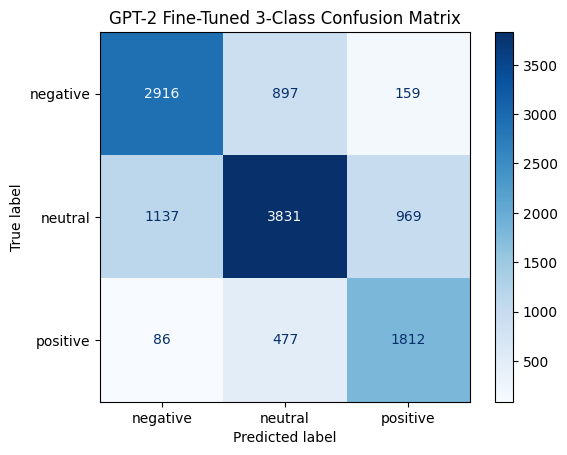

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true_gpt2_3,
    y_pred_gpt2_3,
    labels=[
        "negative",
        "neutral",
        "positive"
    ],
    cmap="Blues"
)

plt.title(
    "GPT-2 Fine-Tuned 3-Class Confusion Matrix"
)

plt.show()

In [ ]:
GPT2_PRED_PATH = (
    "/content/drive/MyDrive/"
    "Sentiment_Project/"
    "gpt2_3class_predictions.csv"
)

test_df.to_csv(
    GPT2_PRED_PATH,
    index=False
)

print("Predictions saved to:")
print(GPT2_PRED_PATH)

Predictions saved to:
/content/drive/MyDrive/Sentiment_Project/gpt2_3class_predictions.csv


In [ ]:
import pandas as pd

# GPT-2 3-class test metrics
gpt2_3class_accuracy = test_results["eval_accuracy"]
gpt2_3class_precision = test_results["eval_precision_macro"]
gpt2_3class_recall = test_results["eval_recall_macro"]
gpt2_3class_f1 = test_results["eval_f1_macro"]

comparison_3class_final = pd.DataFrame({
    "Model": [
        "Twitter-RoBERTa",
        "BERTweet",
        "GPT-2 Fine-Tuned"
    ],

    "Accuracy": [
        0.7222403126017584,
        bertweet_accuracy,
        gpt2_3class_accuracy
    ],

    "Macro Precision": [
        0.7200,
        bertweet_precision,
        gpt2_3class_precision
    ],

    "Macro Recall": [
        0.7353702387640677,
        bertweet_recall,
        gpt2_3class_recall
    ],

    "Macro F1": [
        0.7244332814398557,
        bertweet_f1,
        gpt2_3class_f1
    ]
})

comparison_3class_final = (
    comparison_3class_final
    .round(4)
)

print("=" * 70)
print("FINAL COMPARISON - 3-CLASS SENTIMENT CLASSIFICATION")
print("Dataset : TweetEval")
print("Classes : Negative / Neutral / Positive")
print("Test set: 12,284 tweets")
print("=" * 70)

display(comparison_3class_final)

FINAL COMPARISON - 3-CLASS SENTIMENT CLASSIFICATION
Dataset : TweetEval
Classes : Negative / Neutral / Positive
Test set: 12,284 tweets


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Twitter-RoBERTa,0.7222,0.7200,0.7354,0.7244
1,BERTweet,0.7206,0.7145,0.7302,0.7207
2,GPT-2 Fine-Tuned,0.6968,0.6856,0.7141,0.6962


In [ ]:
ranking_3class = (
    comparison_3class_final
    .sort_values(
        by="Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_3class.index = ranking_3class.index + 1

print("3-Class Model Ranking")
print("Based on Macro F1")
print()

display(ranking_3class)

3-Class Model Ranking
Based on Macro F1



,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Twitter-RoBERTa,0.7222,0.7200,0.7354,0.7244
2,BERTweet,0.7206,0.7145,0.7302,0.7207
3,GPT-2 Fine-Tuned,0.6968,0.6856,0.7141,0.6962


In [ ]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

xlmt = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    device=device
)

print(
    "Device:",
    "GPU" if device == 0 else "CPU"
)

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.11GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device: GPU


In [ ]:
print("id2label:")
print(xlmt.model.config.id2label)

print("\nlabel2id:")
print(xlmt.model.config.label2id)

id2label:
{0: 'negative', 1: 'neutral', 2: 'positive'}

label2id:
{'negative': 0, 'neutral': 1, 'positive': 2}


In [ ]:
if "clean_text" not in test_df.columns:
    test_df["clean_text"] = (
        test_df["text"]
        .apply(preprocess_tweet)
    )

print(
    test_df[
        [
            "text",
            "clean_text",
            "sentiment"
        ]
    ].head()
)

                                                text  \
0  @user @user what do these '1/2 naked pics' hav...   
1  OH: “I had a blue penis while I was this” [pla...   
2  @user @user That's coming, but I think the vic...   
3  I think I may be finally in with the in crowd ...   
4  @user Wow,first Hugo Chavez and now Fidel Cast...   

                                          clean_text sentiment  
0  @user @user what do these '1/2 naked pics' hav...   neutral  
1  OH: “I had a blue penis while I was this” [pla...   neutral  
2  @user @user That's coming, but I think the vic...   neutral  
3  I think I may be finally in with the in crowd ...  positive  
4  @user Wow,first Hugo Chavez and now Fidel Cast...  negative  


In [ ]:
xlmt_predictions = xlmt(
    test_df["clean_text"].tolist(),
    batch_size=32,
    truncation=True,
    max_length=128
)

print(
    "Number of test samples :",
    len(test_df)
)

print(
    "Number of predictions  :",
    len(xlmt_predictions)
)

print("\nFirst 5 predictions:")

print(
    xlmt_predictions[:5]
)

Number of test samples : 12284
Number of predictions  : 12284

First 5 predictions:
[{'label': 'negative', 'score': 0.5787217020988464}, {'label': 'neutral', 'score': 0.8252803087234497}, {'label': 'neutral', 'score': 0.614875853061676}, {'label': 'positive', 'score': 0.5379969477653503}, {'label': 'negative', 'score': 0.7860667705535889}]


In [ ]:
test_df["xlmt_pred"] = [
    pred["label"].lower()
    for pred in xlmt_predictions
]

print(
    test_df[
        [
            "text",
            "sentiment",
            "xlmt_pred"
        ]
    ].head(10)
)

                                                text sentiment xlmt_pred
0  @user @user what do these '1/2 naked pics' hav...   neutral  negative
1  OH: “I had a blue penis while I was this” [pla...   neutral   neutral
2  @user @user That's coming, but I think the vic...   neutral   neutral
3  I think I may be finally in with the in crowd ...  positive  positive
4  @user Wow,first Hugo Chavez and now Fidel Cast...  negative  negative
5  Savchenko now Saakashvili took drug test live ...   neutral  negative
6           How many more days until opening day? 😩    neutral   neutral
7  Twitter's #ThankYouObama Shows Heartfelt Grati...  positive  positive
8  All CSG and Fracking all around Australia is t...   neutral   neutral
9  @user @user @user @user @user @user take away ...  negative   neutral


In [ ]:
print(
    "Missing predictions:",
    test_df["xlmt_pred"].isna().sum()
)

print("\nPrediction distribution:")

print(
    test_df["xlmt_pred"]
    .value_counts()
)

Missing predictions: 0

Prediction distribution:
xlmt_pred
negative    5615
neutral     4235
positive    2434
Name: count, dtype: int64


In [ ]:
from pathlib import Path

SAVE_DIR = Path(
    "/content/drive/MyDrive/Sentiment_Project"
)

SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

XLMT_PRED_PATH = (
    SAVE_DIR /
    "xlmt_3class_predictions.csv"
)

test_df.to_csv(
    XLMT_PRED_PATH,
    index=False
)

print("Predictions saved to:")
print(XLMT_PRED_PATH)

Predictions saved to:
/content/drive/MyDrive/Sentiment_Project/xlmt_3class_predictions.csv


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_true_xlmt = test_df["sentiment"]
y_pred_xlmt = test_df["xlmt_pred"]

xlmt_accuracy = accuracy_score(
    y_true_xlmt,
    y_pred_xlmt
)

xlmt_precision = precision_score(
    y_true_xlmt,
    y_pred_xlmt,
    average="macro",
    zero_division=0
)

xlmt_recall = recall_score(
    y_true_xlmt,
    y_pred_xlmt,
    average="macro",
    zero_division=0
)

xlmt_f1 = f1_score(
    y_true_xlmt,
    y_pred_xlmt,
    average="macro",
    zero_division=0
)

print("XLM-T 3-Class Results")
print("---------------------")

print(
    "Accuracy        :",
    xlmt_accuracy
)

print(
    "Macro Precision :",
    xlmt_precision
)

print(
    "Macro Recall    :",
    xlmt_recall
)

print(
    "Macro F1        :",
    xlmt_f1
)

print("\nClassification Report:")

print(
    classification_report(
        y_true_xlmt,
        y_pred_xlmt,
        labels=[
            "negative",
            "neutral",
            "positive"
        ]
    )
)

XLM-T 3-Class Results
---------------------
Accuracy        : 0.681943992184956
Macro Precision : 0.6892865888849952
Macro Recall    : 0.7061026485595082
Macro F1        : 0.6842345536165793

Classification Report:
              precision    recall  f1-score   support

    negative       0.61      0.87      0.72      3972
     neutral       0.77      0.55      0.64      5937
    positive       0.68      0.70      0.69      2375

    accuracy                           0.68     12284
   macro avg       0.69      0.71      0.68     12284
weighted avg       0.70      0.68      0.68     12284



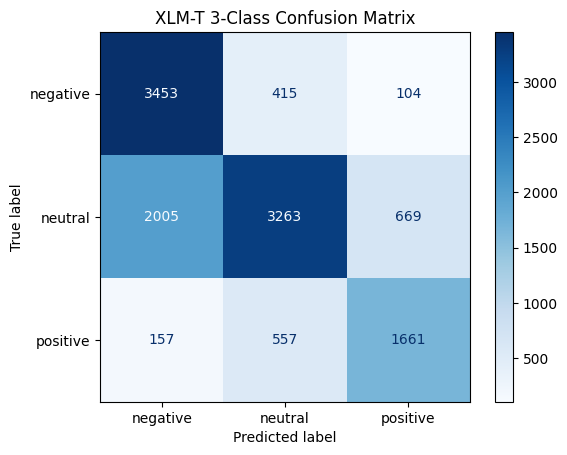

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true_xlmt,
    y_pred_xlmt,
    labels=[
        "negative",
        "neutral",
        "positive"
    ],
    cmap="Blues"
)

plt.title(
    "XLM-T 3-Class Confusion Matrix"
)

plt.show()

In [ ]:
gpt2_3class_accuracy = (
    test_results["eval_accuracy"]
)

gpt2_3class_precision = (
    test_results["eval_precision_macro"]
)

gpt2_3class_recall = (
    test_results["eval_recall_macro"]
)

gpt2_3class_f1 = (
    test_results["eval_f1_macro"]
)

In [ ]:
import pandas as pd

comparison_3class_final = pd.DataFrame({
    "Model": [
        "Twitter-RoBERTa",
        "BERTweet",
        "GPT-2 Fine-Tuned",
        "XLM-T"
    ],

    "Accuracy": [
        0.7222403126017584,
        bertweet_accuracy,
        gpt2_3class_accuracy,
        xlmt_accuracy
    ],

    "Macro Precision": [
        0.7200,
        bertweet_precision,
        gpt2_3class_precision,
        xlmt_precision
    ],

    "Macro Recall": [
        0.7353702387640677,
        bertweet_recall,
        gpt2_3class_recall,
        xlmt_recall
    ],

    "Macro F1": [
        0.7244332814398557,
        bertweet_f1,
        gpt2_3class_f1,
        xlmt_f1
    ]
})

comparison_3class_final = (
    comparison_3class_final
    .round(4)
)

print("=" * 75)
print("FINAL COMPARISON - 3-CLASS SENTIMENT CLASSIFICATION")
print("Dataset : TweetEval")
print("Classes : Negative / Neutral / Positive")
print("Test Set: 12,284 tweets")
print("=" * 75)

display(comparison_3class_final)

FINAL COMPARISON - 3-CLASS SENTIMENT CLASSIFICATION
Dataset : TweetEval
Classes : Negative / Neutral / Positive
Test Set: 12,284 tweets


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Twitter-RoBERTa,0.7222,0.7200,0.7354,0.7244
1,BERTweet,0.7206,0.7145,0.7302,0.7207
2,GPT-2 Fine-Tuned,0.6968,0.6856,0.7141,0.6962
3,XLM-T,0.6819,0.6893,0.7061,0.6842


In [ ]:
ranking_3class = (
    comparison_3class_final
    .sort_values(
        by="Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_3class.index = (
    ranking_3class.index + 1
)

print(
    "3-Class Model Ranking "
    "(Based on Macro F1)"
)

display(ranking_3class)

3-Class Model Ranking (Based on Macro F1)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Twitter-RoBERTa,0.7222,0.7200,0.7354,0.7244
2,BERTweet,0.7206,0.7145,0.7302,0.7207
3,GPT-2 Fine-Tuned,0.6968,0.6856,0.7141,0.6962
4,XLM-T,0.6819,0.6893,0.7061,0.6842


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

GPT2_3CLASS_DIR = Path(
    "/content/drive/MyDrive/Sentiment_Project/gpt2_tweeteval_3class"
)

print("Folder exists:", GPT2_3CLASS_DIR.exists())

if GPT2_3CLASS_DIR.exists():
    print("\nFiles and folders:")

    for item in GPT2_3CLASS_DIR.iterdir():
        print(item.name)

Folder exists: True

Files and folders:
checkpoint-11404
checkpoint-17106
best_model


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "Sentiment_Project/"
    "gpt2_tweeteval_3class/"
    "best_model"
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

print("GPT-2 3-class model loaded successfully.")

print("\nLabels:")
print(model.config.id2label)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

GPT-2 3-class model loaded successfully.

Labels:
{0: 'negative', 1: 'neutral', 2: 'positive'}


In [ ]:
from pathlib import Path

MODEL_PATH = Path(
    "/content/drive/MyDrive/"
    "Sentiment_Project/"
    "gpt2_tweeteval_3class/"
    "best_model"
)

for file in MODEL_PATH.iterdir():
    print(file.name)

config.json
model.safetensors
tokenizer_config.json
tokenizer.json
training_args.bin


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount("/content/drive")
from pathlib import Path

GPT2_BINARY_DIR = Path(
    "/content/drive/MyDrive/"
    "Sentiment_Project/"
    "gpt2_tweeteval_binary"
)

GPT2_BINARY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(GPT2_BINARY_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Sentiment_Project/gpt2_tweeteval_binary


In [ ]:
binary_train = train_df[
    train_df["sentiment"].isin(
        ["negative", "positive"]
    )
].copy()

binary_val = val_df[
    val_df["sentiment"].isin(
        ["negative", "positive"]
    )
].copy()

binary_test = test_df[
    test_df["sentiment"].isin(
        ["negative", "positive"]
    )
].copy()

print("TRAIN")
print(binary_train["sentiment"].value_counts())

print("\nVALIDATION")
print(binary_val["sentiment"].value_counts())

print("\nTEST")
print(binary_test["sentiment"].value_counts())

print("\nDataset sizes")
print("Train      :", len(binary_train))
print("Validation :", len(binary_val))
print("Test       :", len(binary_test))

TRAIN
sentiment
positive    17849
negative     7093
Name: count, dtype: int64

VALIDATION
sentiment
positive    819
negative    312
Name: count, dtype: int64

TEST
sentiment
negative    3972
positive    2375
Name: count, dtype: int64

Dataset sizes
Train      : 24942
Validation : 1131
Test       : 6347


In [ ]:
def preprocess_tweet(text):
    new_text = []

    for token in text.split():

        if token.startswith("@") and len(token) > 1:
            token = "@user"

        elif token.startswith("http"):
            token = "http"

        new_text.append(token)

    return " ".join(new_text)
binary_train["clean_text"] = (
    binary_train["text"]
    .apply(preprocess_tweet)
)

binary_val["clean_text"] = (
    binary_val["text"]
    .apply(preprocess_tweet)
)

binary_test["clean_text"] = (
    binary_test["text"]
    .apply(preprocess_tweet)
)

In [ ]:
binary_label2id = {
    "negative": 0,
    "positive": 1
}

binary_id2label = {
    0: "negative",
    1: "positive"
}

binary_train["binary_label"] = (
    binary_train["sentiment"]
    .map(binary_label2id)
)

binary_val["binary_label"] = (
    binary_val["sentiment"]
    .map(binary_label2id)
)

binary_test["binary_label"] = (
    binary_test["sentiment"]
    .map(binary_label2id)
)

print(
    binary_train[
        ["sentiment", "binary_label"]
    ].head(10)
)

   sentiment  binary_label
0   positive             1
4   positive             1
5   positive             1
6   positive             1
7   negative             0
8   positive             1
12  positive             1
13  negative             0
16  positive             1
17  positive             1


In [ ]:
from datasets import Dataset

train_binary_dataset = Dataset.from_pandas(
    binary_train[
        ["clean_text", "binary_label"]
    ].rename(
        columns={"binary_label": "label"}
    ),
    preserve_index=False
)

val_binary_dataset = Dataset.from_pandas(
    binary_val[
        ["clean_text", "binary_label"]
    ].rename(
        columns={"binary_label": "label"}
    ),
    preserve_index=False
)

test_binary_dataset = Dataset.from_pandas(
    binary_test[
        ["clean_text", "binary_label"]
    ].rename(
        columns={"binary_label": "label"}
    ),
    preserve_index=False
)

print(train_binary_dataset)
print(val_binary_dataset)
print(test_binary_dataset)

Dataset({
    features: ['clean_text', 'label'],
    num_rows: 24942
})
Dataset({
    features: ['clean_text', 'label'],
    num_rows: 1131
})
Dataset({
    features: ['clean_text', 'label'],
    num_rows: 6347
})


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

tokenizer.pad_token = tokenizer.eos_token

print("PAD token    :", tokenizer.pad_token)
print("PAD token ID :", tokenizer.pad_token_id)

PAD token    : <|endoftext|>
PAD token ID : 50256


In [ ]:
MAX_LENGTH = 128

def tokenize_binary(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_binary_tokenized = (
    train_binary_dataset.map(
        tokenize_binary,
        batched=True
    )
)

val_binary_tokenized = (
    val_binary_dataset.map(
        tokenize_binary,
        batched=True
    )
)

test_binary_tokenized = (
    test_binary_dataset.map(
        tokenize_binary,
        batched=True
    )
)

print(train_binary_tokenized)

Map:   0%|          | 0/24942 [00:00<?, ? examples/s]

Map:   0%|          | 0/1131 [00:00<?, ? examples/s]

Map:   0%|          | 0/6347 [00:00<?, ? examples/s]

Dataset({
    features: ['clean_text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 24942
})


In [ ]:
from transformers import DataCollatorWithPadding

binary_data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
from transformers import AutoModelForSequenceClassification

binary_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=2,
        id2label=binary_id2label,
        label2id=binary_label2id
    )
)

binary_model.config.pad_token_id = (
    tokenizer.pad_token_id
)

print(
    "Number of labels:",
    binary_model.config.num_labels
)

print(
    "Labels:",
    binary_model.config.id2label
)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Number of labels: 2
Labels: {0: 'negative', 1: 'positive'}


In [ ]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def compute_binary_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),

        "precision_macro": precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),

        "recall_macro": recall_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),

        "f1_macro": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    }

In [ ]:
from transformers import TrainingArguments

binary_training_args = TrainingArguments(
    output_dir=str(GPT2_BINARY_DIR),

    num_train_epochs=3,

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,

    logging_steps=100,

    fp16=torch.cuda.is_available(),

    report_to="none",

    seed=42
)

In [ ]:
from transformers import Trainer

binary_trainer = Trainer(
    model=binary_model,
    args=binary_training_args,

    train_dataset=train_binary_tokenized,
    eval_dataset=val_binary_tokenized,

    processing_class=tokenizer,
    data_collator=binary_data_collator,

    compute_metrics=compute_binary_metrics
)

print("Binary GPT-2 Trainer ready.")

Binary GPT-2 Trainer ready.


In [ ]:
binary_train_result = (
    binary_trainer.train()
)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.286271,0.273369,0.908046,0.893357,0.872024,0.881793
2,0.188371,0.321719,0.914235,0.896041,0.887210,0.891469
3,0.153326,0.375254,0.915119,0.899623,0.884844,0.891807


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
GPT2_BINARY_FINAL_DIR = (
    GPT2_BINARY_DIR /
    "final_model"
)

binary_trainer.save_model(
    str(GPT2_BINARY_FINAL_DIR)
)

tokenizer.save_pretrained(
    str(GPT2_BINARY_FINAL_DIR)
)

print("GPT-2 binary model saved to:")
print(GPT2_BINARY_FINAL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

GPT-2 binary model saved to:
/content/drive/MyDrive/Sentiment_Project/gpt2_tweeteval_binary/final_model


In [ ]:
binary_test_results = (
    binary_trainer.evaluate(
        test_binary_tokenized
    )
)

print("GPT-2 Fine-Tuned Binary Results")
print("--------------------------------")

print(
    "Accuracy        :",
    binary_test_results[
        "eval_accuracy"
    ]
)

print(
    "Macro Precision :",
    binary_test_results[
        "eval_precision_macro"
    ]
)

print(
    "Macro Recall    :",
    binary_test_results[
        "eval_recall_macro"
    ]
)

print(
    "Macro F1        :",
    binary_test_results[
        "eval_f1_macro"
    ]
)

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.153326,0.350232,3,0.922798,0.913503,0.927484,0.919066


GPT-2 Fine-Tuned Binary Results
--------------------------------
Accuracy        : 0.9227981723648968
Macro Precision : 0.9135033051209123
Macro Recall    : 0.9274836486987863
Macro F1        : 0.9190657835293432


In [ ]:
binary_prediction_output = (
    binary_trainer.predict(
        test_binary_tokenized
    )
)

binary_logits = (
    binary_prediction_output.predictions
)

gpt2_binary_pred_ids = np.argmax(
    binary_logits,
    axis=-1
)

gpt2_binary_predictions = [
    binary_id2label[int(label_id)]
    for label_id
    in gpt2_binary_pred_ids
]

binary_test[
    "gpt2_tweeteval_pred"
] = gpt2_binary_predictions

display(
    binary_test[
        [
            "text",
            "sentiment",
            "gpt2_tweeteval_pred"
        ]
    ].head(10)
)

,text,sentiment,gpt2_tweeteval_pred
3,I think I may be finally in with the in crowd ...,positive,positive
4,"@user Wow,first Hugo Chavez and now Fidel Cast...",negative,positive
7,Twitter's #ThankYouObama Shows Heartfelt Grati...,positive,positive
9,@user @user @user @user @user @user take away ...,negative,negative
12,#onedirection #harrystyles cute little dance 😉,positive,positive
13,"When Ryan privatizes SS, Medicare, Medicaid, &...",negative,negative
14,Swampbitch Nasty Pelosi loves yelling 'Fire' ...,negative,negative
21,@user Going to see #FantasticBeasts this after...,positive,positive
26,The left has really gone Full retard haven't t...,negative,negative
33,Can't wait to try this - Google Earth VR - thi...,positive,positive


In [ ]:
from sklearn.metrics import classification_report

y_true_gpt2_binary = (
    binary_test["sentiment"]
)

y_pred_gpt2_binary = (
    binary_test[
        "gpt2_tweeteval_pred"
    ]
)

print(
    classification_report(
        y_true_gpt2_binary,
        y_pred_gpt2_binary,
        labels=[
            "negative",
            "positive"
        ]
    )
)

              precision    recall  f1-score   support

    negative       0.97      0.91      0.94      3972
    positive       0.86      0.95      0.90      2375

    accuracy                           0.92      6347
   macro avg       0.91      0.93      0.92      6347
weighted avg       0.93      0.92      0.92      6347



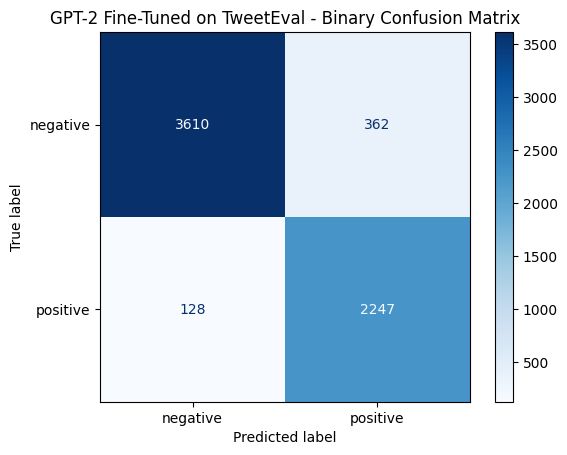

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true_gpt2_binary,
    y_pred_gpt2_binary,
    labels=[
        "negative",
        "positive"
    ],
    cmap="Blues"
)

plt.title(
    "GPT-2 Fine-Tuned on TweetEval "
    "- Binary Confusion Matrix"
)

plt.show()

In [ ]:
GPT2_BINARY_PRED_PATH = (
    "/content/drive/MyDrive/"
    "Sentiment_Project/"
    "gpt2_tweeteval_binary_predictions.csv"
)

binary_test.to_csv(
    GPT2_BINARY_PRED_PATH,
    index=False
)

print("Predictions saved to:")
print(GPT2_BINARY_PRED_PATH)

Predictions saved to:
/content/drive/MyDrive/Sentiment_Project/gpt2_tweeteval_binary_predictions.csv


In [ ]:
gpt2_tweeteval_accuracy = (
    binary_test_results["eval_accuracy"]
)

gpt2_tweeteval_precision = (
    binary_test_results["eval_precision_macro"]
)

gpt2_tweeteval_recall = (
    binary_test_results["eval_recall_macro"]
)

gpt2_tweeteval_f1 = (
    binary_test_results["eval_f1_macro"]
)

print("GPT-2 Fine-Tuned on TweetEval")
print("--------------------------------")
print("Accuracy        :", gpt2_tweeteval_accuracy)
print("Macro Precision :", gpt2_tweeteval_precision)
print("Macro Recall    :", gpt2_tweeteval_recall)
print("Macro F1        :", gpt2_tweeteval_f1)

GPT-2 Fine-Tuned on TweetEval
--------------------------------
Accuracy        : 0.9227981723648968
Macro Precision : 0.9135033051209123
Macro Recall    : 0.9274836486987863
Macro F1        : 0.9190657835293432


In [ ]:
import pandas as pd

comparison_binary_final = pd.DataFrame({
"Model": [
    "GPT-2 Fine-Tuned on IMDB",
    "GPT-2 Fine-Tuned on TweetEval",
    "Twitter-RoBERTa",
    "BERTweet",
    "DistilBERT"
],

    "Accuracy": [
        0.5360012604380022,
        gpt2_tweeteval_accuracy,
        0.9462738301559792,
        bertweet_binary_accuracy,
        distilbert_accuracy
    ],

    "Macro Precision": [
        0.5350,
        gpt2_tweeteval_precision,
        0.9400,
        bertweet_binary_precision,
        distilbert_precision
    ],

    "Macro Recall": [
        0.5333770074733661,
        gpt2_tweeteval_recall,
        0.9441238140668893,
        bertweet_binary_recall,
        distilbert_recall
    ],

    "Macro F1": [
        0.526087310924977,
        gpt2_tweeteval_f1,
        0.942810097037712,
        bertweet_binary_f1,
        distilbert_f1
    ]
})

comparison_binary_final = comparison_binary_final.round(4)

print("=" * 80)
print("FINAL BINARY SENTIMENT CLASSIFICATION COMPARISON")
print("Dataset : TweetEval")
print("Classes : Negative / Positive")
print("Test Set: 6,347 tweets")
print("=" * 80)

display(comparison_binary_final)

FINAL BINARY SENTIMENT CLASSIFICATION COMPARISON
Dataset : TweetEval
Classes : Negative / Positive
Test Set: 6,347 tweets


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,GPT-2 Fine-Tuned on IMDB,0.5360,0.5350,0.5334,0.5261
1,GPT-2 Fine-Tuned on TweetEval,0.9228,0.9135,0.9275,0.9191
2,Twitter-RoBERTa,0.9463,0.9400,0.9441,0.9428
3,BERTweet,0.9420,0.9351,0.9430,0.9387
4,DistilBERT,0.8130,0.8078,0.7855,0.7935


In [12]:
# ============================================================
# 3-CLASS CLASSIFICATION REPORT TABLES
# Negative / Neutral / Positive
# ============================================================

from IPython.display import display, HTML


models_3class = {

    "Twitter-RoBERTa": {
        "Negative": [0.69, 0.81, 0.74, 3972],
        "Neutral":  [0.76, 0.66, 0.70, 5937],
        "Positive": [0.71, 0.74, 0.73, 2375],
        "Accuracy": 0.72,
        "Macro Avg": [0.72, 0.74, 0.72],
        "Weighted Avg": [0.73, 0.72, 0.72]
    },

    "BERTweet": {
        "Negative": [0.71, 0.79, 0.75, 3972],
        "Neutral":  [0.75, 0.67, 0.71, 5937],
        "Positive": [0.69, 0.73, 0.71, 2375],
        "Accuracy": 0.72,
        "Macro Avg": [0.71, 0.73, 0.72],
        "Weighted Avg": [0.72, 0.72, 0.72]
    },

    "GPT-2 Fine-Tuned": {
        "Negative": [0.70, 0.73, 0.72, 3972],
        "Neutral":  [0.74, 0.65, 0.69, 5937],
        "Positive": [0.62, 0.76, 0.68, 2375],
        "Accuracy": 0.70,
        "Macro Avg": [0.69, 0.71, 0.70],
        "Weighted Avg": [0.70, 0.70, 0.70]
    },

    "XLM-T": {
        "Negative": [0.61, 0.87, 0.72, 3972],
        "Neutral":  [0.77, 0.55, 0.64, 5937],
        "Positive": [0.68, 0.70, 0.69, 2375],
        "Accuracy": 0.68,
        "Macro Avg": [0.69, 0.71, 0.68],
        "Weighted Avg": [0.70, 0.68, 0.68]
    }
}


classes = [
    "Negative",
    "Neutral",
    "Positive"
]

total_support = 12284


# ============================================================
# HTML STYLE
# ============================================================

html = """
<style>

.report-container {
    max-width: 820px;
    font-family: Arial, sans-serif;
}

.model-title {
    font-size: 22px;
    margin-top: 30px;
    margin-bottom: 10px;
}

.report-table {
    border-collapse: collapse;
    width: 100%;
    margin-bottom: 30px;
    font-size: 18px;
}

.report-table th,
.report-table td {
    border: 1px solid #444;
    padding: 9px 14px;
}

.report-table th {
    text-align: center;
}

.report-table td:first-child {
    text-align: left;
}

.report-table td:not(:first-child) {
    text-align: right;
}

</style>

<div class="report-container">

<h2>3-Class Sentiment Classification</h2>
<p>Negative / Neutral / Positive</p>
<p>Test set: 12,284 tweets</p>
"""


# ============================================================
# CREATE TABLE FOR EACH MODEL
# ============================================================

for model_name, result in models_3class.items():

    html += f"""
    <div class="model-title">
        {model_name}
    </div>

    <table class="report-table">

        <tr>
            <th>Class</th>
            <th>Precision</th>
            <th>Recall</th>
            <th>F1-Score</th>
            <th>Support</th>
        </tr>
    """


    # Class rows
    for class_name in classes:

        precision, recall, f1, support = result[class_name]

        html += f"""
        <tr>
            <td>{class_name}</td>
            <td>{precision:.2f}</td>
            <td>{recall:.2f}</td>
            <td>{f1:.2f}</td>
            <td>{support:,}</td>
        </tr>
        """


    # Accuracy
    html += f"""
    <tr>
        <td>Accuracy</td>
        <td></td>
        <td></td>
        <td>{result["Accuracy"]:.2f}</td>
        <td>{total_support:,}</td>
    </tr>
    """


    # Macro Average
    macro_p, macro_r, macro_f1 = result["Macro Avg"]

    html += f"""
    <tr>
        <td>Macro Avg</td>
        <td>{macro_p:.2f}</td>
        <td>{macro_r:.2f}</td>
        <td>{macro_f1:.2f}</td>
        <td>{total_support:,}</td>
    </tr>
    """


    # Weighted Average
    weighted_p, weighted_r, weighted_f1 = result["Weighted Avg"]

    html += f"""
    <tr>
        <td>Weighted Avg</td>
        <td>{weighted_p:.2f}</td>
        <td>{weighted_r:.2f}</td>
        <td>{weighted_f1:.2f}</td>
        <td>{total_support:,}</td>
    </tr>

    </table>
    """


html += "</div>"

display(HTML(html))

Class,Precision,Recall,F1-Score,Support
Negative,0.69,0.81,0.74,"3,972"
Neutral,0.76,0.66,0.70,"5,937"
Positive,0.71,0.74,0.73,"2,375"
Accuracy,,,0.72,"12,284"
Macro Avg,0.72,0.74,0.72,"12,284"
Weighted Avg,0.73,0.72,0.72,"12,284"
Class,Precision,Recall,F1-Score,Support
Negative,0.71,0.79,0.75,"3,972"
Neutral,0.75,0.67,0.71,"5,937"
Positive,0.69,0.73,0.71,"2,375"


In [13]:
# ============================================================
# BINARY CLASSIFICATION REPORT TABLES
# Negative / Positive
# ============================================================

from IPython.display import display, HTML


models_binary = {

    "GPT-2 Previous": {
        "Negative": [0.66, 0.54, 0.59, 3972],
        "Positive": [0.41, 0.52, 0.46, 2375],
        "Accuracy": 0.54,
        "Macro Avg": [0.53, 0.53, 0.53],
        "Weighted Avg": [0.56, 0.54, 0.54]
    },

    "DistilBERT": {
        "Negative": [0.82, 0.89, 0.86, 3972],
        "Positive": [0.79, 0.68, 0.73, 2375],
        "Accuracy": 0.81,
        "Macro Avg": [0.81, 0.79, 0.79],
        "Weighted Avg": [0.81, 0.81, 0.81]
    },

    "GPT-2 Fine-Tuned": {
        "Negative": [0.97, 0.91, 0.94, 3972],
        "Positive": [0.86, 0.95, 0.90, 2375],
        "Accuracy": 0.92,
        "Macro Avg": [0.91, 0.93, 0.92],
        "Weighted Avg": [0.93, 0.92, 0.92]
    },

    "BERTweet": {
        "Negative": [0.97, 0.94, 0.95, 3972],
        "Positive": [0.90, 0.95, 0.92, 2375],
        "Accuracy": 0.94,
        "Macro Avg": [0.94, 0.94, 0.94],
        "Weighted Avg": [0.94, 0.94, 0.94]
    },

    "Twitter-RoBERTa": {
        "Negative": [0.96, 0.95, 0.96, 3972],
        "Positive": [0.92, 0.94, 0.93, 2375],
        "Accuracy": 0.95,
        "Macro Avg": [0.94, 0.94, 0.94],
        "Weighted Avg": [0.95, 0.95, 0.95]
    }
}


classes = [
    "Negative",
    "Positive"
]

total_support = 6347


# ============================================================
# HTML STYLE
# ============================================================

html = """
<style>

.report-container {
    max-width: 820px;
    font-family: Arial, sans-serif;
}

.model-title {
    font-size: 22px;
    margin-top: 30px;
    margin-bottom: 10px;
}

.report-table {
    border-collapse: collapse;
    width: 100%;
    margin-bottom: 30px;
    font-size: 18px;
}

.report-table th,
.report-table td {
    border: 1px solid #444;
    padding: 9px 14px;
}

.report-table th {
    text-align: center;
}

.report-table td:first-child {
    text-align: left;
}

.report-table td:not(:first-child) {
    text-align: right;
}

</style>

<div class="report-container">

<h2>Binary Sentiment Classification</h2>
<p>Negative / Positive</p>
<p>Test set: 6,347 tweets</p>
"""


# ============================================================
# CREATE TABLE FOR EACH MODEL
# ============================================================

for model_name, result in models_binary.items():

    html += f"""
    <div class="model-title">
        {model_name}
    </div>

    <table class="report-table">

        <tr>
            <th>Class</th>
            <th>Precision</th>
            <th>Recall</th>
            <th>F1-Score</th>
            <th>Support</th>
        </tr>
    """


    # Class rows
    for class_name in classes:

        precision, recall, f1, support = result[class_name]

        html += f"""
        <tr>
            <td>{class_name}</td>
            <td>{precision:.2f}</td>
            <td>{recall:.2f}</td>
            <td>{f1:.2f}</td>
            <td>{support:,}</td>
        </tr>
        """


    # Accuracy
    html += f"""
    <tr>
        <td>Accuracy</td>
        <td></td>
        <td></td>
        <td>{result["Accuracy"]:.2f}</td>
        <td>{total_support:,}</td>
    </tr>
    """


    # Macro Average
    macro_p, macro_r, macro_f1 = result["Macro Avg"]

    html += f"""
    <tr>
        <td>Macro Avg</td>
        <td>{macro_p:.2f}</td>
        <td>{macro_r:.2f}</td>
        <td>{macro_f1:.2f}</td>
        <td>{total_support:,}</td>
    </tr>
    """


    # Weighted Average
    weighted_p, weighted_r, weighted_f1 = result["Weighted Avg"]

    html += f"""
    <tr>
        <td>Weighted Avg</td>
        <td>{weighted_p:.2f}</td>
        <td>{weighted_r:.2f}</td>
        <td>{weighted_f1:.2f}</td>
        <td>{total_support:,}</td>
    </tr>

    </table>
    """


html += "</div>"

display(HTML(html))

Class,Precision,Recall,F1-Score,Support
Negative,0.66,0.54,0.59,"3,972"
Positive,0.41,0.52,0.46,"2,375"
Accuracy,,,0.54,"6,347"
Macro Avg,0.53,0.53,0.53,"6,347"
Weighted Avg,0.56,0.54,0.54,"6,347"
Class,Precision,Recall,F1-Score,Support
Negative,0.82,0.89,0.86,"3,972"
Positive,0.79,0.68,0.73,"2,375"
Accuracy,,,0.81,"6,347"
Macro Avg,0.81,0.79,0.79,"6,347"


In [14]:
# ============================================================
# EXPORT CLASSIFICATION REPORT TABLES TO JPG
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from google.colab import files


def export_report_to_jpg(
    models_data,
    classes,
    total_support,
    report_title,
    output_path
):
    """
    Create classification-report tables for all models
    and save them as one high-resolution JPG image.
    """

    num_models = len(models_data)

    # Create a tall figure
    fig, axes = plt.subplots(
        num_models,
        1,
        figsize=(11, num_models * 3.4)
    )

    # Make sure axes is always iterable
    axes = np.atleast_1d(axes)

    for ax, (model_name, result) in zip(
        axes,
        models_data.items()
    ):

        ax.axis("off")

        # Model title
        ax.set_title(
            model_name,
            loc="left",
            fontsize=15,
            fontweight="bold",
            pad=10
        )

        # ----------------------------------------------------
        # Create table rows
        # ----------------------------------------------------

        rows = []

        # Individual classes
        for class_name in classes:

            precision, recall, f1, support = (
                result[class_name]
            )

            rows.append([
                class_name,
                f"{precision:.2f}",
                f"{recall:.2f}",
                f"{f1:.2f}",
                f"{support:,}"
            ])

        # Accuracy
        rows.append([
            "Accuracy",
            "",
            "",
            f"{result['Accuracy']:.2f}",
            f"{total_support:,}"
        ])

        # Macro average
        macro_p, macro_r, macro_f1 = (
            result["Macro Avg"]
        )

        rows.append([
            "Macro Avg",
            f"{macro_p:.2f}",
            f"{macro_r:.2f}",
            f"{macro_f1:.2f}",
            f"{total_support:,}"
        ])

        # Weighted average
        weighted_p, weighted_r, weighted_f1 = (
            result["Weighted Avg"]
        )

        rows.append([
            "Weighted Avg",
            f"{weighted_p:.2f}",
            f"{weighted_r:.2f}",
            f"{weighted_f1:.2f}",
            f"{total_support:,}"
        ])

        # ----------------------------------------------------
        # Draw table
        # ----------------------------------------------------

        table = ax.table(
            cellText=rows,
            colLabels=[
                "Class",
                "Precision",
                "Recall",
                "F1-Score",
                "Support"
            ],
            cellLoc="right",
            colLoc="center",
            loc="center",
            bbox=[0, 0, 1, 0.85],
            colWidths=[
                0.28,
                0.18,
                0.16,
                0.20,
                0.18
            ]
        )

        table.auto_set_font_size(False)
        table.set_fontsize(12)

        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        for (row, col), cell in table.get_celld().items():

            cell.set_linewidth(0.8)

            # Header
            if row == 0:
                cell.get_text().set_fontweight("bold")
                cell.get_text().set_ha("center")

            # First column aligned left
            elif col == 0:
                cell.get_text().set_ha("left")

            else:
                cell.get_text().set_ha("right")

    # Main title
    fig.suptitle(
        report_title,
        fontsize=18,
        fontweight="bold",
        y=0.995
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.98]
    )

    # Save JPG
    plt.savefig(
        output_path,
        format="jpg",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print("Saved:")
    print(output_path)


# ============================================================
# EXPORT 3-CLASS REPORT
# ============================================================

path_3class = (
    "/content/"
    "3class_classification_report.jpg"
)

export_report_to_jpg(
    models_data=models_3class,
    classes=[
        "Negative",
        "Neutral",
        "Positive"
    ],
    total_support=12284,
    report_title=(
        "3-Class Sentiment Classification\n"
        "Negative / Neutral / Positive"
    ),
    output_path=path_3class
)


# ============================================================
# EXPORT BINARY REPORT
# ============================================================

path_binary = (
    "/content/"
    "binary_classification_report.jpg"
)

export_report_to_jpg(
    models_data=models_binary,
    classes=[
        "Negative",
        "Positive"
    ],
    total_support=6347,
    report_title=(
        "Binary Sentiment Classification\n"
        "Negative / Positive"
    ),
    output_path=path_binary
)


# ============================================================
# DOWNLOAD BOTH JPG FILES
# ============================================================

files.download(path_3class)
files.download(path_binary)

Saved:
/content/3class_classification_report.jpg
Saved:
/content/binary_classification_report.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>